In [1]:
# Task 3
# Workflow
# Use qc filtered dataset, compute hvg and select perturbations (all) present in 3 contitions with > 15 cells present each perturbation
# Select 50 perturbations regarding pathway information first
# Use Ridge regression and Random Forest as model ( before doing it in a loop)
# Try different selection strategies and use loops for it
# Use Ridge Regression, Random Forest and DummyRegressor as baseline model 
# Evaluate the models via Pearson correlation, RMSE, MAE and 95% perturbation-level

In [2]:
# import packages
import scanpy as sc
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

In [3]:
#Load the data
adata = sc.read_h5ad("../data/frangieh/adata_qc_done.h5ad")

In [4]:
#Print the column names
print(adata.obs.columns)

Index(['library_preparation_protocol', 'condition', 'MOI', 'sgRNA',
       'UMI_count', 'guide_id', 'perturbation', 'tissue_type', 'cancer',
       'disease', 'perturbation_type', 'celltype', 'organism',
       'perturbation_type_2', 'nperts', 'ngenes', 'ncounts', 'percent_mito',
       'percent_ribo', 'n_genes_by_counts', 'log1p_n_genes_by_counts',
       'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes',
       'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes',
       'pct_counts_in_top_500_genes', 'total_counts_mt',
       'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo',
       'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb',
       'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts',
       'doublet_scores', 'predicted_doublets', 'doublet_info'],
      dtype='object')


In [5]:
# Cell counts across Control, IFNγ, and Co-culture conditions
print(adata.obs["condition"].value_counts())

condition
IFNγ          74186
Co-culture    67093
Control       49895
Name: count, dtype: int64


In [8]:
# Define the variables
RANDOM_STATE = 42
MIN_CELLS = 15
N_PERTURBATIONS = 50
N_TEST = 10
N_HVG = 2000
PERT_COL = "perturbation"
COND_COL = "condition"
CONDITIONS = ["Control", "IFNγ", "Co-culture"]
UNPERTURBED_LABEL = "control"

In [9]:
# Cell counts for perturbation x condition
counts = (
    adata.obs
    .groupby([PERT_COL, COND_COL], observed=True)
    .size()
    .unstack(fill_value=0)
)

# Keep only the conditions to use
available_conditions = [
    c for c in CONDITIONS
    if c in counts.columns
]

print("Available conditions:", available_conditions)

# Keep perturbations with >= MIN_CELLS in every condition
eligible = counts[
    (counts[available_conditions] >= MIN_CELLS).all(axis=1)
].index.tolist()

print("Eligible perturbations:", len(eligible))

Available conditions: ['Control', 'IFNγ', 'Co-culture']
Eligible perturbations: 238


In [10]:
# Define possible labels used for unperturbed or non-targeting control cells
CONTROL_NAMES = {
    "control",
    "ctrl",
    "nt",
    "ntc",
    "non-targeting",
    "nontargeting",
    "non_targeting"
}

# Remove control/non-targeting labels from the list of eligible perturbations,
# since only actual gene perturbations should be considered for the 50-gene selection
eligible = [
    gene for gene in eligible
    if str(gene).lower() not in CONTROL_NAMES
]

# Display the number of eligible gene perturbations remaining after control removal
print("Eligible real perturbations:", len(eligible))

Eligible real perturbations: 237


In [11]:
#install gseapy
import sys
!{sys.executable} -m pip install gseapy

In [12]:
# Version of gseapy
import gseapy as gp
print(gp.__version__)

1.3.1


In [13]:
#Download Hallmark pathway annotations
hallmark = gp.get_library(
    name="MSigDB_Hallmark_2020",
    organism="Human"
)
print("Number of pathways:", len(hallmark))

Number of pathways: 50


In [14]:
# Convert all gene names in the Hallmark pathway dictionary to uppercase
# to ensure consistent gene-name matching regardless of capitalization
hallmark_upper = {
    pathway: {str(g).upper() for g in genes}
    for pathway, genes in hallmark.items()
}

In [15]:
# Create a dictionary mapping each eligible perturbation gene
# to its uppercase version for consistent matching with Hallmark gene names
eligible_upper = {
    gene: str(gene).upper()
    for gene in eligible
}

# Initialize a binary pathway-membership matrix:
# rows = eligible perturbation genes
# columns = Hallmark pathways
# 0 = gene is not part of the pathway
# 1 = gene is part of the pathway
pathway_matrix = pd.DataFrame(
    0,
    index=eligible,
    columns=hallmark_upper.keys(),
    dtype=int
)

# Check each eligible perturbation gene against every Hallmark pathway
for gene in eligible:

    # Retrieve the uppercase version of the perturbation gene
    gene_upper = eligible_upper[gene]

    for pathway, pathway_genes in hallmark_upper.items():

        # Mark the gene as 1 if it belongs to the corresponding Hallmark pathway
        if gene_upper in pathway_genes:
            pathway_matrix.loc[gene, pathway] = 1

In [16]:
# Display the dimensions of the pathway-membership matrix
# (number of eligible perturbation × number of Hallmark pathways)
print(pathway_matrix.shape)

# Display the first five perturbations and their binary pathway memberships
# to verify that the pathway annotation matrix was constructed correctly
pathway_matrix.head()

(237, 50)


,TNF-alpha Signaling via NF-kB,Hypoxia,Cholesterol Homeostasis,Mitotic Spindle,Wnt-beta Catenin Signaling,TGF-beta Signaling,IL-6/JAK/STAT3 Signaling,DNA Repair,G2-M Checkpoint,Apoptosis,...,heme Metabolism,Coagulation,IL-2/STAT5 Signaling,Bile Acid Metabolism,Pperoxisome,Allograft Rejection,Spermatogenesis,KRAS Signaling Up,KRAS Signaling Dn,Pancreas Beta Cells
A2M,0,0,0,0,0,0,1,0,0,0,...,0,1,0,0,0,0,0,0,0,0
ACSL3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ACTA2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AEBP1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AGA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [17]:
#Count how many Hallmark pathways annotate each perturbation:
gene_pathway_count = pathway_matrix.sum(axis=1)
gene_pathway_count.sort_values(
    ascending=False
).head(20)

CDKN1A    10
MYC       10
CD44       8
CCND1      7
CCND2      7
TIMP1      7
TGFB1      7
FOS        6
IFNGR2     5
CDK4       5
JAK2       5
CXCR4      5
IFNGR1     5
KLF4       5
NOLC1      5
SAT1       5
MT2A       4
IDH2       4
TP53       4
NME1       4
dtype: int64

In [18]:
# Display how many eligible perturbations are represented in each pathway:
pathway_gene_count = pathway_matrix.sum(axis=0)
pathway_gene_count.sort_values(
    ascending=False
)

Myc Targets V1                       18
E2F Targets                          15
Allograft Rejection                  15
Interferon Gamma Response            14
p53 Pathway                          14
Estrogen Response Late               13
Apoptosis                            13
G2-M Checkpoint                      12
KRAS Signaling Up                    12
Complement                           12
IL-2/STAT5 Signaling                 11
TNF-alpha Signaling via NF-kB        10
Epithelial Mesenchymal Transition    10
mTORC1 Signaling                      9
Coagulation                           9
Glycolysis                            9
Estrogen Response Early               8
Xenobiotic Metabolism                 8
Oxidative Phosphorylation             8
Myogenesis                            7
Adipogenesis                          7
Androgen Response                     7
Hypoxia                               7
IL-6/JAK/STAT3 Signaling              7
Inflammatory Response                 7


In [19]:
# Identify perturbations with no pathway annotation
no_pathway = pathway_matrix.index[
    pathway_matrix.sum(axis=1) == 0
].tolist()

print("Eligible genes without Hallmark annotation:")
print(no_pathway)

print(
    "Annotated:",
    len(eligible) - len(no_pathway),
    "/",
    len(eligible)
)

Eligible genes without Hallmark annotation:
['AGA', 'ARMC6', 'ATP5MD', 'BOLA2B', 'BZW2', 'C6orf226', 'C19orf48', 'CCR10', 'CD58', 'CDC123', 'CDH19', 'CGAS', 'CHCHD2', 'CITED1', 'CMSS1', 'CSPG4', 'CST3', 'CTSA', 'DAG1', 'DDR1', 'DDX17', 'DLL3', 'EEA1', 'EEF1G', 'EIF3K', 'EVA1A', 'FBXO32', 'FMN1', 'FOXM1', 'FRZB', 'FTH1', 'GAS5', 'GPATCH4', 'GRN', 'GSEC', 'HASPIN', 'HLA-DRB5', 'HLA-H', 'IDI2-AS1', 'IRF3', 'ISYNA1', 'JMJD7', 'KDR', 'LEF1-AS1', 'LINC00518', 'LRRC75A-AS1', 'MC1R', 'MFGE8', 'MIA', 'MRPL47', 'NACA', 'NDUFA13', 'NEAT1', 'NGFR', 'NMRK1', 'NONO', 'NPC2', 'NSG1', 'NUP50-AS1', 'PET100', 'PFDN4', 'PIK3IP1', 'PSAP', 'PSMB8-AS1', 'PTMA', 'PUF60', 'RBP7', 'ROMO1', 'RPSA', 'RRS1', 'S100A6', 'S100B', 'SAE1', 'SCARB2', 'SEC11C', 'SERPINF1', 'SINHCAF', 'SLC5A3', 'SLC7A5P1', 'SLIRP', 'SMAD4', 'SNHG6', 'SOX4', 'SP100', 'SPESP1', 'SPINT1', 'SSR2', 'ST3GAL6-AS1', 'TAPBPL', 'TFAP2A', 'TMEM173', 'TOP1MT', 'TPP1', 'TRIM22', 'TSC22D3', 'TTLL1', 'TXNDC17', 'UCN2', 'VAT1', 'WBP2', 'XAGE1A']
Annotat

In [20]:
# Keep only perturbations with at least one pathway annotation
annotated_genes = pathway_matrix.index[
    pathway_matrix.sum(axis=1) > 0
].tolist()

In [21]:
# Select 50 perturbations that maximize pathway coverage
rng = np.random.default_rng(42)
annotated_genes = pathway_matrix.index[
    pathway_matrix.sum(axis=1) > 0
].tolist()
selected_50_pathway = []
covered_pathways = set()
remaining = annotated_genes.copy()

In [22]:
# Iteratively select perturbation genes until 50 genes have been chosen
# or no eligible genes remain
while len(selected_50_pathway) < 50 and len(remaining) > 0:

    # Store how many previously uncovered pathways each remaining gene would add
    gains = {}

    for gene in remaining:

        # Identify all Hallmark pathways associated with the current gene
        gene_pathways = set(
            pathway_matrix.columns[
                pathway_matrix.loc[gene] == 1
            ]
        )

        # Determine which of these pathways have not yet been represented
        # by the already selected perturbations
        new_pathways = gene_pathways - covered_pathways

        # Record the number of new pathways that this gene would contribute
        gains[gene] = len(new_pathways)

    # Find the largest number of new pathways contributed by any remaining gene
    max_gain = max(gains.values())

    # Identify all genes that provide the maximum additional pathway coverage
    best_genes = [
        gene for gene, gain in gains.items()
        if gain == max_gain
    ]

    # Randomly choose one gene if several genes provide the same maximum gain
    # (using the predefined random generator for reproducibility)
    chosen = rng.choice(best_genes)

    # Add the selected gene to the final set of perturbations
    selected_50_pathway.append(chosen)

    # Retrieve all Hallmark pathways associated with the newly selected gene
    gene_pathways = set(
        pathway_matrix.columns[
            pathway_matrix.loc[chosen] == 1
        ]
    )

    # Update the set of pathways already represented by the selected genes
    covered_pathways.update(gene_pathways)

    # Remove the selected gene so that it cannot be selected again
    remaining.remove(chosen)

In [23]:
# If the pathway-based selection produced fewer than 50 perturbations,
# fill the remaining positions with other eligible perturbation genes
if len(selected_50_pathway) < 50:

    # Identify eligible genes that have not already been selected
    remaining_eligible = [
        gene for gene in eligible
        if gene not in selected_50_pathway
    ]

    # Randomly select enough additional genes to reach a total of 50
    # without selecting the same gene more than once
    extra = rng.choice(
        remaining_eligible,
        size=50 - len(selected_50_pathway),
        replace=False
    )

    # Add the randomly selected genes to the final perturbation set
    selected_50_pathway.extend(extra.tolist())

In [24]:
#Show selected perturbations and hallmark pathways represented
print("Selected perturbations:", len(selected_50_pathway))

print(
    "Hallmark pathways represented:",
    pathway_matrix.loc[selected_50_pathway]
    .max(axis=0)
    .sum()
)

Selected perturbations: 50
Hallmark pathways represented: 46


In [25]:
# Count how many of the 50 selected perturbation genes are associated
# with each pathway
selected_pathway_counts = (
    pathway_matrix
    .loc[selected_50_pathway]             # Keep only the 50 selected perturbation genes
    .sum(axis=0)                  # Count pathway memberships across these genes
    .sort_values(ascending=False) # Sort pathways from most to least represented
)

# Display only Hallmark pathways represented by at least one
# of the 50 selected perturbation genes
selected_pathway_counts[
    selected_pathway_counts > 0
]

Allograft Rejection                  9
Estrogen Response Late               8
Complement                           7
Myc Targets V1                       7
TNF-alpha Signaling via NF-kB        7
G2-M Checkpoint                      6
E2F Targets                          6
p53 Pathway                          6
Estrogen Response Early              5
Androgen Response                    5
Interferon Gamma Response            5
mTORC1 Signaling                     5
Coagulation                          5
Apoptosis                            5
Myogenesis                           4
Inflammatory Response                4
Oxidative Phosphorylation            4
heme Metabolism                      4
KRAS Signaling Up                    4
Epithelial Mesenchymal Transition    3
TGF-beta Signaling                   3
DNA Repair                           3
PI3K/AKT/mTOR  Signaling             2
Apical Junction                      2
Adipogenesis                         2
IL-6/JAK/STAT3 Signaling 

In [26]:
#import packages
from scipy import sparse

# Create a copy of the original AnnData object so that normalization
# and log transformation for HVG selection do not modify the original data
adata_hvg = adata.copy()

# Normalize gene-expression counts 
sc.pp.normalize_total(
    adata_hvg,
    target_sum=1e4
)

# Apply a log transformation
sc.pp.log1p(adata_hvg)

# Compute HVGs
sc.pp.highly_variable_genes(
    adata_hvg,
    n_top_genes=2000
)

# Extract the names of the 2,000 selected HVGs
# that will be used to represent the transcriptomic response
response_hvgs = adata_hvg.var_names[
    adata_hvg.var["highly_variable"]
].tolist()

# Verify that 2,000 HVGs were selected and display the first 20 genes
print("Number of HVGs:", len(response_hvgs))
print(response_hvgs[:20])

Number of HVGs: 2000
['AADAC', 'AATBC', 'ABCB11', 'ABCB6', 'ABHD12B', 'ABL2', 'AC002310.2', 'AC002347.1', 'AC002384.1', 'AC003092.1', 'AC003956.1', 'AC004112.1', 'AC004231.1', 'AC004232.2', 'AC004448.2', 'AC004471.2', 'AC004528.1', 'AC004584.1', 'AC004771.4', 'AC004771.5']


In [27]:
# Use the HVGs as the response genes
# whose mean log2 fold-change values will be predicted by the models
response_genes = response_hvgs

In [29]:
#import packages
import numpy as np
from scipy import sparse

# Pseudocount added when calculating log2 fold changes later
PSEUDOCOUNT = 1


# Define a function to calculate the mean expression of the selected
# response genes across all cells in an AnnData subset
def mean_expression(adata_subset, genes):

    # Extract the expression matrix for the selected response genes
    X = adata_subset[:, genes].X

    # Calculate the mean expression of each gene across all cells
    if sparse.issparse(X):
        mean = np.asarray(
            X.mean(axis=0)
        ).ravel()
    else:
        mean = np.asarray(
            X.mean(axis=0)
        ).ravel()

    # Return one mean expression value for each response gene
    return mean

In [30]:
# Define the label used to identify unperturbed/control cells
# in the perturbation column
UNPERTURBED_LABEL = "control"

# Define the three experimental conditions included in the analysis
CONDITIONS = ["Control", "IFNγ", "Co-culture"]

# Define the AnnData observation column containing the
# CRISPR perturbation target for each cell
PERT_COL = "perturbation"

# Define the AnnData observation column containing the
# experimental condition for each cell
COND_COL = "condition"

In [31]:
# Create a Boolean mask to identify unperturbed/control cells
baseline_means = {}

for condition in adata.obs[COND_COL].unique():

    # Select unperturbed/control cells within the current condition
    baseline_mask = (
        (adata.obs[COND_COL] == condition)
        &
        (
            adata.obs[PERT_COL]
            .astype(str)
            .str.lower()
            == UNPERTURBED_LABEL.lower()
        )
    )

    # Subset baseline cells
    baseline_adata = adata[baseline_mask]

    # Calculate mean expression of the response genes
    baseline_means[condition] = mean_expression(
        baseline_adata,
        response_genes
    )

    print(
        condition,
        "baseline cells:",
        baseline_mask.sum()
    )

Control baseline cells: 12941
IFNγ baseline cells: 20192
Co-culture baseline cells: 16708


In [32]:
#import packages
from scipy import sparse
import numpy as np

# Access the gene-expression matrix from the AnnData object
X = adata.X

# Extract the stored expression values depending on whether
# the expression matrix is sparse or dense
if sparse.issparse(X):
    values = X.data
else:
    values = np.asarray(X).ravel()

# Check the expression matrix for missing (NaN) or infinite values
# and inspect its numerical range
print("NaN:", np.isnan(values).sum())
print("Inf:", np.isinf(values).sum())
print("Min:", np.nanmin(values))
print("Max:", np.nanmax(values))

# Display the first 20 stored expression values to inspect
# the scale and format of the expression data
print("First values:")
print(values[:20])

NaN: 0
Inf: 0
Min: 1.0
Max: 4437.0
First values:
[2. 1. 1. 1. 1. 2. 1. 1. 2. 2. 1. 1. 2. 5. 1. 1. 1. 1. 2. 1.]


In [33]:
# Initialize a list to store the condition-specific
# transcriptional response profiles for the 50 selected perturbations
profiles = []

# Loop through the three experimental conditions
for condition in CONDITIONS:

    # Identify unperturbed/control cells within the current condition
    baseline_mask = (
        (adata.obs[COND_COL] == condition)
        &
        (
            adata.obs[PERT_COL]
            .astype(str)
            .str.lower()
            == UNPERTURBED_LABEL.lower()
        )
    )

    # Extract the condition-matched unperturbed cells
    baseline_adata = adata[baseline_mask]

    # Display the number of baseline cells available
    # for the current experimental condition
    print(
        condition,
        "baseline cells:",
        baseline_adata.n_obs
    )

    # Calculate the mean expression of the 2,000 response genes
    # in the unperturbed cells of the current condition
    baseline_mean = mean_expression(
        baseline_adata,
        response_genes
    )

    # Loop through each of the 50 selected perturbation targets
    for pert in selected_50_pathway:

        # Identify cells carrying the current perturbation
        # within the current experimental condition
        pert_mask = (
            (adata.obs[COND_COL] == condition)
            &
            (adata.obs[PERT_COL] == pert)
        )

        # Extract the corresponding perturbed cells
        pert_adata = adata[pert_mask]

        # Skip perturbation-condition combinations with fewer
        # than the minimum required number of cells
        if pert_adata.n_obs < MIN_CELLS:
            continue

        # Calculate the mean expression of the 2,000 response genes
        # for the current perturbation-condition combination
        pert_mean = mean_expression(
            pert_adata,
            response_genes
        )

        # Calculate the mean log2 fold change for each response gene
        # relative to the condition-matched unperturbed baseline.
        # The pseudocount prevents division by zero.
        log2fc = np.log2(
            (pert_mean + PSEUDOCOUNT)
            /
            (baseline_mean + PSEUDOCOUNT)
        )

        # Store the perturbation name, experimental condition,
        # number of cells, and 2,000-gene log2FC response vector
        profiles.append({
            "perturbation": pert,
            "condition": condition,
            "n_cells": pert_adata.n_obs,
            "log2fc": log2fc
        })

Control baseline cells: 12941
IFNγ baseline cells: 20192
Co-culture baseline cells: 16708


In [34]:
#Check number of profiles
print("Number of profiles:", len(profiles))

Number of profiles: 150


In [35]:
# Create the target matrix Y with the mean log2 fold-change
# response for each perturbation and condition

# Create a table containing the perturbation, condition,
# and number of cells for each response profile
profile_metadata = pd.DataFrame([
    {
        "perturbation": p["perturbation"],
        "condition": p["condition"],
        "n_cells": p["n_cells"]
    }
    for p in profiles
])

# Combine the log2FC profiles into one matrix
# Rows = perturbation-condition profiles
# Columns = 2,000 HVGs
Y = np.vstack([
    p["log2fc"]
    for p in profiles
])

# Check the dimensions
# 50 perturbations × 3 conditions = 150 profiles
print("Metadata:", profile_metadata.shape)
print("Target Y:", Y.shape)

Metadata: (150, 3)
Target Y: (150, 2000)


In [36]:
# Initialize a list that will store the input feature vector
# for each perturbation-condition profile
X_rows = []

# Loop through each row of the profile metadata table
for _, row in profile_metadata.iterrows():

    # Get the perturbation target gene for the current profile
    gene = row["perturbation"]

    # Get the experimental condition for the current profile
    condition = row["condition"]

    # Retrieve the Hallmark pathway membership features
    # of the current perturbation gene
    features = pathway_matrix.loc[gene].copy()

    # Add the experimental condition as one-hot encoded features.
    # Exactly one of these three variables will be equal to 1.
    features["condition_Control"] = int(
        condition == "Control"
    )

    features["condition_IFNγ"] = int(
        condition == "IFNγ"
    )

    features["condition_Co-culture"] = int(
        condition == "Co-culture"
    )

    # Add the complete feature vector for this
    # perturbation-condition profile to the input list
    X_rows.append(features)


# Convert the list of feature vectors into the final input matrix X.
# Rows = perturbation-condition profiles
# Columns = Hallmark pathway features + experimental condition features
X = pd.DataFrame(
    X_rows
).reset_index(drop=True)

# Check that the input and target matrices contain
# the same number of perturbation-condition profiles
print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (150, 53)
Y shape: (150, 2000)


In [38]:
# Extract the Hallmark pathway-membership information
# for the 50 selected perturbation genes
selected_pathway_matrix = pathway_matrix.loc[selected_50_pathway]

# Identify selected perturbation genes that are not annotated
# to any of the Hallmark pathways.
# A row sum of 0 means that the gene has no Hallmark pathway membership.
zero_pathway_genes = selected_pathway_matrix.index[
    selected_pathway_matrix.sum(axis=1) == 0
].tolist()

# Display the selected perturbations for which no
# Hallmark pathway annotation was found
print(
    "Selected genes without Hallmark annotation:",
    zero_pathway_genes
)

Selected genes without Hallmark annotation: []


In [39]:
import warnings

warnings.filterwarnings(
    "ignore",
    message=".*sklearn.utils.parallel.delayed.*"
)

In [40]:
# Different Selection methods for 50 features
##a) 50 most frequent pertubations
##b) 50 randomly selected pertubations
##c) 50 pertubations with highest LFC
##d) cluster pertubations and select pertubations from each cluster -> most different
## e) pathway informed selection ( perturbations with maximal diverse pathways annotation would be selected)
#### this was saved as selected_50_pathway above

In [41]:
# (a) Select the most 50 frequent perturbations
# Count cells for each perturbation
# and exclude the unperturbed control
perturbation_counts = (
    adata.obs[
        adata.obs["perturbation"] != "control"
    ]["perturbation"]
    .value_counts()
)

# Restrict the ranking to Hallmark-annotated perturbations
perturbation_counts_annotated = (
    perturbation_counts[
        perturbation_counts.index.isin(
            annotated_genes
        )
    ]
)

# Select the 50 most frequent annotated perturbations
top50_perturbations = (
    perturbation_counts_annotated
    .head(50)
    .index
    .tolist()
)

print(
    "Most frequent selected:",
    len(top50_perturbations)
)


Most frequent selected: 50


In [42]:
# Select random 50 perturbations 
random50_perturbations = rng.choice(
    annotated_genes,
    size=50,
    replace=False
).tolist()

print(
    "Random selected:",
    len(random50_perturbations)
)

Random selected: 50


In [43]:
# c) Select 50 perturbations with the highest transcriptional response

pert_strength = {}

# Calculate response strength for ALL Hallmark-annotated eligible perturbations
for pert in annotated_genes:

    condition_strengths = []

    for condition in CONDITIONS:

        # Select cells for this perturbation and condition
        pert_mask = (
            (adata.obs[COND_COL] == condition)
            &
            (adata.obs[PERT_COL] == pert)
        )

        pert_adata = adata[pert_mask]

        # Skip combinations with too few cells
        if pert_adata.n_obs < MIN_CELLS:
            continue

        # Mean expression of the perturbation
        pert_mean = mean_expression(
            pert_adata,
            response_genes
        )

        # Condition-matched unperturbed baseline
        baseline_mean = baseline_means[
            condition
        ]

        # Calculate log2FC
        log2fc = np.log2(
            (pert_mean + PSEUDOCOUNT)
            /
            (baseline_mean + PSEUDOCOUNT)
        )

        # Mean absolute response across the 2,000 HVGs
        strength = np.mean(
            np.abs(log2fc)
        )

        condition_strengths.append(
            strength
        )

    # Use strongest response across the three conditions
    if len(condition_strengths) > 0:
        pert_strength[pert] = max(
            condition_strengths
        )


# Convert to Series
pert_strength = pd.Series(
    pert_strength
)

print(
    "Perturbations with calculated LFC strength:",
    len(pert_strength)
)


# Select the 50 perturbations with the strongest response
top_lfc50_perturbations = (
    pert_strength
    .sort_values(ascending=False)
    .head(50)
    .index
    .tolist()
)

print(
    "Highest LFC selected:",
    len(top_lfc50_perturbations)
)

Perturbations with calculated LFC strength: 136
Highest LFC selected: 50


In [44]:
# Prepare the data
# Keep only Hallmark-annotated perturbations
adata_annotated = adata[
    adata.obs["perturbation"].isin(annotated_genes)
].copy()

# Calculate the mean expression profile for each perturbation
# across all cells belonging to that perturbation
perturbation_names = (
    adata_annotated.obs["perturbation"]
    .astype(str)
    .unique()
)

mean_profiles = []

for pert in perturbation_names:

    tmp = adata_annotated[
        adata_annotated.obs["perturbation"] == pert
    ]

    X = tmp.X

    if sparse.issparse(X):
        mean_profile = np.asarray(
            X.mean(axis=0)
        ).ravel()
    else:
        mean_profile = np.asarray(
            X.mean(axis=0)
        ).ravel()

    mean_profiles.append(
        mean_profile
    )


# Create an AnnData object with one row per perturbation
adata_perts_combined = sc.AnnData(
    X=np.vstack(mean_profiles)
)

adata_perts_combined.obs["perturbation"] = (
    perturbation_names
)

adata_perts_combined.var_names = (
    adata_annotated.var_names.copy()
)

In [45]:
# install packages
%pip install leidenalg igraph

Note: you may need to restart the kernel to use updated packages.


In [46]:
# PCA and leiden clustering on perturbation profiles
# import packags
import scanpy as sc
import leidenalg
import igraph
# Reduce dimensionality
sc.pp.pca(
    adata_perts_combined,
    n_comps=50
)

# Build a nearest-neighbor graph
sc.pp.neighbors(
    adata_perts_combined,
    n_pcs=20
)

# Perform Leiden clustering
sc.tl.leiden(
    adata_perts_combined,
    resolution=0.6,
    random_state=42
)

print(
    adata_perts_combined.obs[
        "leiden"
    ].value_counts()
)

leiden
0    42
1    38
2    35
3    21
Name: count, dtype: int64


In [47]:

# (d) Select 50 perturbations across different Leiden clusters

# Get the Leiden cluster assigned to each perturbation
cluster_series = adata_perts_combined.obs["leiden"]

# Count the number of Leiden clusters
n_clusters = cluster_series.nunique()

# Calculate approximately how many perturbations
# should be selected from each cluster
samples_per_cluster = int(
    np.ceil(50 / n_clusters)
)

# Create an empty list to store the selected perturbations
cluster50_perturbations = []


# Go through each Leiden cluster separately
for cluster_id in sorted(
    cluster_series.unique()
):

    # Get all unique perturbations belonging to this cluster
    cluster_perts = (
        adata_perts_combined.obs.loc[
            cluster_series == cluster_id,
            "perturbation"
        ]
        .unique()
        .tolist()
    )

    # Select the calculated number of perturbations,
    # or all perturbations if the cluster contains fewer
    n_sample = min(
        samples_per_cluster,
        len(cluster_perts)
    )

    # Randomly select perturbations from the current cluster
    chosen = rng.choice(
        cluster_perts,
        size=n_sample,
        replace=False
    ).tolist()

    # Add the selected perturbations to the final list
    cluster50_perturbations.extend(
        chosen
    )


# Remove possible duplicate perturbations
cluster50_perturbations = list(
    dict.fromkeys(
        cluster50_perturbations
    )
)

In [48]:
# Reduce to exactly 50 if too many were selected
if len(cluster50_perturbations) > 50:

    cluster50_perturbations = rng.choice(
        cluster50_perturbations,
        size=50,
        replace=False
    ).tolist()


# Fill to 50 if too few were selected
elif len(cluster50_perturbations) < 50:

    available_genes = (
        adata_leiden.obs["perturbation"]
        .unique()
        .tolist()
    )

    remaining_genes = [
        gene
        for gene in available_genes
        if gene not in cluster50_perturbations
    ]

    n_needed = (
        50 - len(cluster50_perturbations)
    )

    extra = rng.choice(
        remaining_genes,
        size=n_needed,
        replace=False
    ).tolist()

    cluster50_perturbations.extend(
        extra
    )


print(
    "Leiden-cluster selected:",
    len(cluster50_perturbations)
)

Leiden-cluster selected: 50


In [49]:
# Selection sets for 50 perturbation selection
selection_sets = {
    "Most frequent": top50_perturbations,
    "Random": random50_perturbations,
    "Highest LFC": top_lfc50_perturbations,
    "Leiden clusters": cluster50_perturbations,
    "Pathway": selected_50_pathway,
}

In [50]:
# Import required packages

import numpy as np
import pandas as pd

from scipy import sparse
from scipy.stats import pearsonr

from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge

from sklearn.model_selection import (
    GroupKFold,
    RandomizedSearchCV,
    GridSearchCV
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)


# Analysis settings
RANDOM_STATE = 42
MIN_CELLS = 15
PSEUDOCOUNT = 1

PERT_COL = "perturbation"
COND_COL = "condition"

UNPERTURBED_LABEL = "control"

CONDITIONS = [
    "Control",
    "IFNγ",
    "Co-culture"
]

# Number of PCs used for the target response
N_TARGET_PCS = 50

# Number of PCs used to represent the
# unperturbed control baseline
N_BASELINE_PCS = 50

In [51]:
# Use the 2,000 highly variable genes as response genes

response_genes = (
    adata_hvg.var_names[
        adata_hvg.var["highly_variable"]
    ]
    .astype(str)
    .tolist()
)

print(
    "Number of response genes:",
    len(response_genes)
)

Number of response genes: 2000


In [52]:
# Check the available gene-level annotations
print(adata_hvg.var.columns)

Index(['ensembl_id', 'ncounts', 'ncells', 'mt', 'ribo', 'hb',
       'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts',
       'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts',
       'n_cells', 'highly_variable', 'means', 'dispersions',
       'dispersions_norm'],
      dtype='object')


In [53]:
# Calculate mean expression of selected genes
# across cells in an AnnData subset

def mean_expression(
    adata__hvg_subset,
    genes
):

    X = adata__hvg_subset[:, genes].X

    if sparse.issparse(X):
        mean = np.asarray(
            X.mean(axis=0)
        ).ravel()

    else:
        mean = np.asarray(
            X.mean(axis=0)
        ).ravel()

    return mean

In [54]:

# Calculate unperturbed control expression profiles
# separately for each experimental condition

baseline_means = {}

for condition in CONDITIONS:

    control_mask = (
        (adata.obs[COND_COL] == condition)
        &
        (
            adata.obs[PERT_COL]
            .astype(str)
            .str.lower()
            == UNPERTURBED_LABEL.lower()
        )
    )

    control_adata = adata[
        control_mask
    ]

    print(
        condition,
        "control cells:",
        control_adata.n_obs
    )

    baseline_means[condition] = mean_expression(
        control_adata,
        response_genes
    )

Control control cells: 12941
IFNγ control cells: 20192
Co-culture control cells: 16708


In [55]:

# Represent the unperturbed control profiles using PCs

# Use the cell-level expression of all unperturbed
# control cells from all three conditions to fit PCA

control_mask_all = (
    adata.obs[PERT_COL]
    .astype(str)
    .str.lower()
    == UNPERTURBED_LABEL.lower()
)

control_adata_all = adata[
    control_mask_all,
    response_genes
].copy()


# Convert to dense matrix if necessary
X_control = control_adata_all.X

if sparse.issparse(X_control):
    X_control = X_control.toarray()

X_control = np.asarray(
    X_control
)


# Fit PCA on unperturbed control cells
pca_baseline = PCA(
    n_components=N_BASELINE_PCS,
    random_state=RANDOM_STATE
)

pca_baseline.fit(
    X_control
)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",50
,"random_state random_state: int, RandomState instance or None, default=NoneUsed when the 'arpack' or 'randomized' solvers are used. Pass an intfor reproducible results across multiple function calls.See :term:`Glossary <random_state>`... versionadded:: 0.18.0",42
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to e

In [56]:
# Calculate the mean control profile in PCA space
# separately for each condition

baseline_pc_profiles = {}

for condition in CONDITIONS:

    control_mask = (
        (adata.obs[COND_COL] == condition)
        &
        (
            adata.obs[PERT_COL]
            .astype(str)
            .str.lower()
            == UNPERTURBED_LABEL.lower()
        )
    )

    control_condition = adata[
        control_mask,
        response_genes
    ]

    X_condition = control_condition.X

    if sparse.issparse(X_condition):
        X_condition = X_condition.toarray()

    X_condition = np.asarray(
        X_condition
    )

    # Transform control cells into baseline PCA space
    control_pcs = pca_baseline.transform(
        X_condition
    )

    # Mean PC profile for this condition
    baseline_pc_profiles[condition] = (
        control_pcs.mean(axis=0)
    )


print(
    "Baseline PC dimensions:",
    {
        condition: len(vector)
        for condition, vector
        in baseline_pc_profiles.items()
    }
)

Baseline PC dimensions: {'Control': 50, 'IFNγ': 50, 'Co-culture': 50}


In [57]:
# Model hyperparameter search
rf_param_dist = {
    "n_estimators": [100,200,300, 400],
    "max_depth": [3,6,9,12, None],
    "min_samples_split": [2, 4, 6, 8],
    "min_samples_leaf": [1,2,3, 4],
    "max_features": ["sqrt", "log2", 0.5, 1.0]}
ridge_param_grid = {"alpha": [0.01, 0.1, 1, 10, 100]}

In [58]:
# Calculate 95% bootstrap confidence intervals
def bootstrap_metrics(
    Y_true,
    Y_pred,
    metadata,
    n_bootstraps=1000,
    random_state=42
):

    rng = np.random.default_rng(random_state)

    # Get the unique test perturbations
    test_genes = metadata["perturbation"].unique()

    bootstrap_mae = []
    bootstrap_rmse = []
    bootstrap_pearson = []

    # Repeat bootstrap resampling
    for _ in range(n_bootstraps):

        # Sample test perturbations with replacement
        sampled_genes = rng.choice(
            test_genes,
            size=len(test_genes),
            replace=True
        )

        true_profiles = []
        pred_profiles = []
        correlations = []

        # Collect the profiles of the sampled perturbations
        for gene in sampled_genes:

            idx = np.where(
                metadata["perturbation"].values == gene
            )[0]

            true_profiles.append(
                Y_true[idx]
            )

            pred_profiles.append(
                Y_pred[idx]
            )

            # Calculate Pearson correlation
            # for each perturbation profile
            for i in idx:

                if (
                    np.std(Y_true[i]) > 0
                    and np.std(Y_pred[i]) > 0
                ):

                    r, _ = pearsonr(
                        Y_true[i],
                        Y_pred[i]
                    )

                    correlations.append(r)

        # Combine the sampled profiles
        true_profiles = np.vstack(true_profiles)
        pred_profiles = np.vstack(pred_profiles)

        # Calculate performance for this bootstrap sample
        bootstrap_mae.append(
            mean_absolute_error(
                true_profiles.ravel(),
                pred_profiles.ravel()
            )
        )

        bootstrap_rmse.append(
            np.sqrt(
                mean_squared_error(
                    true_profiles.ravel(),
                    pred_profiles.ravel()
                )
            )
        )

        bootstrap_pearson.append(
            np.nanmean(correlations)
        )

    # Calculate the 95% confidence intervals
    mae_ci = np.percentile(
        bootstrap_mae,
        [2.5, 97.5]
    )

    rmse_ci = np.percentile(
        bootstrap_rmse,
        [2.5, 97.5]
    )

    pearson_ci = np.nanpercentile(
        bootstrap_pearson,
        [2.5, 97.5]
    )

    return mae_ci, rmse_ci, pearson_ci

In [59]:
# Train Random Forest, Ridge and baseline for each selection strategy
all_results = []
# Store condition-specific performance results
all_condition_results = []
# Go through each of the selection strategies
for selection_name, selected_50 in selection_sets.items():

    print("\n")
    print("=" * 70)
    print("Selection strategy:", selection_name)
    print("=" * 70)

    # Make sure the perturbations are unique
    selected_50 = list(
        dict.fromkeys(
            selected_50
        )
    )
    # Check the number of selected perturbations
    print(
        "Selected perturbations:",
        len(selected_50)
    )

    if len(selected_50) != 50:

        raise ValueError(
            f"{selection_name} does not contain "
            "exactly 50 unique perturbations."
        )
    
    # Create the transcriptomic response profiles
    profiles = []
    # Go through each experimental condition
    for condition in CONDITIONS:
        # Get the mean expression of the unperturbed control
        # for the current condition
        baseline_mean = baseline_means[
            condition
        ]
        # Go through the 50 selected perturbations
        for pert in selected_50:
            # Select cells belonging to the current
            # perturbation and condition
            pert_mask = (
                (adata.obs[COND_COL] == condition)
                &
                (adata.obs[PERT_COL] == pert)
            )

            pert_adata = adata[
                pert_mask
            ]
            pert_mean = mean_expression(
                pert_adata,
                response_genes
            )

            # Calculate log2FC relative to the
            # condition-matched unperturbed control
            log2fc = np.log2(
                (pert_mean + PSEUDOCOUNT)
                /
                (baseline_mean + PSEUDOCOUNT)
            )

            profiles.append({

                "perturbation":
                    pert,

                "condition":
                    condition,

                "n_cells":
                    pert_adata.n_obs,

                "log2fc":
                    log2fc
            })
    # Create metadata and target matrix Y
    
    profile_metadata = pd.DataFrame([
        {
            "perturbation":
                p["perturbation"],

            "condition":
                p["condition"],

            "n_cells":
                p["n_cells"]
        }

        for p in profiles
    ])

    # Combine the log2FC profiles into the target matrix Y
    # Each row represents one perturbation-condition profile
    # and each column represents one response gene
    Y = np.vstack([
        p["log2fc"]
        for p in profiles
    ])


    print(
        "Profiles:",
        profile_metadata.shape
    )

    print(
        "Y:",
        Y.shape
    )

  
    # Create Model 1 input matrix X
    #
    # Input features:
    # 1. Hallmark pathway annotations
    # 2. Experimental condition
    # 3. Unperturbed control baseline PCs
    # Create an empty list to store the input features
    X_rows = []
    # Go through each perturbation-condition profile
    for _, row in profile_metadata.iterrows():
        # Get the perturbation gene
        gene = row[
            "perturbation"
        ]
        # Get the experimental condition
        condition = row[
            "condition"
        ]


        # Hallmark pathway annotations
        features = pathway_matrix.loc[
            gene
        ].copy()


        # Experimental condition
        features[
            "condition_Control"
        ] = int(
            condition == "Control"
        )

        features[
            "condition_IFNγ"
        ] = int(
            condition == "IFNγ"
        )

        features[
            "condition_Co-culture"
        ] = int(
            condition == "Co-culture"
        )


        # Condition-matched unperturbed
        # control baseline
        baseline_vector = (
            baseline_pc_profiles[
                condition
            ]
        )


        # Add all 50 baseline PCs
        for i in range(
            N_BASELINE_PCS
        ):

            features[
                f"baseline_PC{i+1}"
            ] = baseline_vector[i]


        X_rows.append(
            features
        )

    # Combine the input features from all
    # perturbation-condition profiles into one DataFrame.
    # Each row of X represents one perturbation under one condition,
    # and the columns contain the features used by the models.
    X = pd.DataFrame(
        X_rows
    ).reset_index(drop=True)


    print(
        "X:",
        X.shape
    )

    # Split the 50 selected perturbations into
    # 40 training and 10 held-out test perturbations

    rng_split = np.random.default_rng(
        RANDOM_STATE
    )

    selected_array = np.array(
        selected_50
    )

    rng_split.shuffle(
        selected_array
    )

    # Select 10 perturbations for the test set
    test_genes = selected_array[
        :10
    ].tolist()

    # Use the remaining 40 perturbations for training
    train_genes = selected_array[
        10:
    ].tolist()

    print(
        "Training perturbations:",
        len(train_genes)
    )

    print(
        "Test perturbations:",
        len(test_genes)
    )
    # Create train and test datasets
    train_mask = (
        profile_metadata[
            "perturbation"
        ]
        .isin(
            train_genes
        )
    )

    test_mask = (
        profile_metadata[
            "perturbation"
        ]
        .isin(
            test_genes
        )
    )


    X_train = (
        X.loc[
            train_mask
        ]
        .reset_index(
            drop=True
        )
    )

    X_test = (
        X.loc[
            test_mask
        ]
        .reset_index(
            drop=True
        )
    )


    Y_train = Y[
        train_mask.values
    ]

    Y_test = Y[
        test_mask.values
    ]

    meta_train = (
        profile_metadata.loc[
            train_mask
        ]
        .reset_index(
            drop=True
        )
    )

    meta_test = (
        profile_metadata.loc[
            test_mask
        ]
        .reset_index(
            drop=True
        )
    )


    print(
        "X_train:",
        X_train.shape
    )

    print(
        "X_test:",
        X_test.shape
    )

    print(
        "Y_train:",
        Y_train.shape
    )

    print(
        "Y_test:",
        Y_test.shape
    )

    # Reduce the 2,000-gene response to 50 PCs

    pca_y = PCA(
        n_components=N_TARGET_PCS,
        random_state=RANDOM_STATE
    )


    # PCA is fitted only on training data
    Y_train_pca = (
        pca_y.fit_transform(
            Y_train
        )
    )


    Y_test_pca = (
        pca_y.transform(
            Y_test
        )
    )


    print(
        "Explained variance by 50 PCs:",
        pca_y.explained_variance_ratio_
        .sum()
    )

    # Grouped cross-validation

    train_groups = (
        meta_train[
            "perturbation"
        ]
        .values
    )


    cv = GroupKFold(
        n_splits=5
    )


    # RANDOM FOREST


    rf = RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1
    )


    rf_search = RandomizedSearchCV(

        estimator=rf,

        param_distributions=
            rf_param_dist,

        n_iter=6,

        scoring=
            "neg_mean_squared_error",

        cv=cv,

        random_state=
            RANDOM_STATE,

        n_jobs=-1,

        verbose=0
    )


    rf_search.fit(
        X_train,
        Y_train_pca,
        groups=train_groups
    )


    best_rf = (
        rf_search
        .best_estimator_
    )


    # Predict test profiles
    Y_pred_pca_rf = (
        best_rf.predict(
            X_test
        )
    )


    # Return to 2,000-gene space
    Y_pred_rf = (
        pca_y.inverse_transform(
            Y_pred_pca_rf
        )
    )

    # RIDGE REGRESSION

    ridge = Ridge()


    ridge_search = GridSearchCV(

        estimator=ridge,

        param_grid=
            ridge_param_grid,

        scoring=
            "neg_mean_squared_error",

        cv=cv,

        n_jobs=-1
    )


    ridge_search.fit(
        X_train,
        Y_train_pca,
        groups=train_groups
    )


    best_ridge = (
        ridge_search
        .best_estimator_
    )


    # Predict the test profiles
    Y_pred_pca_ridge = (
        best_ridge.predict(
            X_test
        )
    )


    # Return to 2,000-gene space
    Y_pred_ridge = (
        pca_y.inverse_transform(
            Y_pred_pca_ridge
        )
    )
    # DUMMY REGRESSOR BASELINE

    from sklearn.dummy import DummyRegressor

    # Create a simple baseline model that always predicts
    # the mean response of the training data
    dummy = DummyRegressor(
        strategy="mean"
    )
    
    # Fit the baseline model
    dummy.fit(
        X_train,
        Y_train_pca
    )
    
    # Predict the test profiles
    Y_pred_pca_dummy = dummy.predict(
        X_test
    )
    
    # Transform the predictions back to the
    # original 2,000-gene log2FC space
    Y_pred_dummy = pca_y.inverse_transform(
        Y_pred_pca_dummy
    )
        
    # Evaluate Random Forest, Ridge and baseline model separately for each condition

    for condition in CONDITIONS:
    
        # Select test profiles belonging to the current condition
        condition_mask = (
            meta_test["condition"] == condition
        ).to_numpy()
    
        Y_true_condition = Y_test[
            condition_mask
        ]
    
        Y_pred_rf_condition = Y_pred_rf[
            condition_mask
        ]
    
        Y_pred_ridge_condition = Y_pred_ridge[
            condition_mask
        ]
        # Dummy baseline predictions for the current condition
        Y_pred_dummy_condition = Y_pred_dummy[
        condition_mask
        ]
        # Random Forest performance
    
        mae_rf_condition = mean_absolute_error(
            Y_true_condition.ravel(),
            Y_pred_rf_condition.ravel()
        )
    
        rmse_rf_condition = np.sqrt(
            mean_squared_error(
                Y_true_condition.ravel(),
                Y_pred_rf_condition.ravel()
            )
        )
    
        pearson_rf_condition = []
    
        for i in range(len(Y_true_condition)):
    
            if (
                np.std(Y_true_condition[i]) > 0
                and
                np.std(Y_pred_rf_condition[i]) > 0
            ):
    
                r, _ = pearsonr(
                    Y_true_condition[i],
                    Y_pred_rf_condition[i]
                )
    
                pearson_rf_condition.append(r)
    
        mean_pearson_rf_condition = np.nanmean(
            pearson_rf_condition
        )
    
    
        
        # Ridge performance
       
        mae_ridge_condition = mean_absolute_error(
            Y_true_condition.ravel(),
            Y_pred_ridge_condition.ravel()
        )
    
        rmse_ridge_condition = np.sqrt(
            mean_squared_error(
                Y_true_condition.ravel(),
                Y_pred_ridge_condition.ravel()
            )
        )
    
        pearson_ridge_condition = []
    
        for i in range(len(Y_true_condition)):
    
            if (
                np.std(Y_true_condition[i]) > 0
                and
                np.std(Y_pred_ridge_condition[i]) > 0
            ):
    
                r, _ = pearsonr(
                    Y_true_condition[i],
                    Y_pred_ridge_condition[i]
                )
    
                pearson_ridge_condition.append(r)
    
        mean_pearson_ridge_condition = np.nanmean(
            pearson_ridge_condition
        )
    
                # Dummy baseline performance
        
        mae_dummy_condition = mean_absolute_error(
            Y_true_condition.ravel(),
            Y_pred_dummy_condition.ravel()
        )
        
        rmse_dummy_condition = np.sqrt(
            mean_squared_error(
                Y_true_condition.ravel(),
                Y_pred_dummy_condition.ravel()
            )
        )
        
        pearson_dummy_condition = []
        
        for i in range(len(Y_true_condition)):
        
            if (
                np.std(Y_true_condition[i]) > 0
                and
                np.std(Y_pred_dummy_condition[i]) > 0
            ):
        
                r, _ = pearsonr(
                    Y_true_condition[i],
                    Y_pred_dummy_condition[i]
                )
        
                pearson_dummy_condition.append(r)
        
        mean_pearson_dummy_condition = np.nanmean(
            pearson_dummy_condition
        )
            
      # Get the metadata for the current condition
        meta_condition = (
            meta_test.loc[
                condition_mask
            ]
            .reset_index(drop=True)
        )
        
        
        # Calculate 95% bootstrap confidence intervals
        # for Random Forest
        mae_ci_rf, rmse_ci_rf, pearson_ci_rf = bootstrap_metrics(
            Y_true_condition,
            Y_pred_rf_condition,
            meta_condition,
            n_bootstraps=1000,
            random_state=42
        )
        
        
        # Calculate 95% bootstrap confidence intervals
        # for Ridge Regression
        mae_ci_ridge, rmse_ci_ridge, pearson_ci_ridge = bootstrap_metrics(
            Y_true_condition,
            Y_pred_ridge_condition,
            meta_condition,
            n_bootstraps=1000,
            random_state=42
        )
        
        
        # Calculate 95% bootstrap confidence intervals
        # for the Dummy baseline
        mae_ci_dummy, rmse_ci_dummy, pearson_ci_dummy = bootstrap_metrics(
            Y_true_condition,
            Y_pred_dummy_condition,
            meta_condition,
            n_bootstraps=1000,
            random_state=42
        )
    
       # Store results

       # Store performance results and 95% bootstrap confidence intervals
        all_condition_results.append({
        
            "Strategy": selection_name,
            "Condition": condition,
        
            # Dummy baseline
            "MAE Baseline": mae_dummy_condition,
            "MAE Baseline low": mae_ci_dummy[0],
            "MAE Baseline high": mae_ci_dummy[1],
        
            "RMSE Baseline": rmse_dummy_condition,
            "RMSE Baseline low": rmse_ci_dummy[0],
            "RMSE Baseline high": rmse_ci_dummy[1],
        
            "Pearson r Baseline": mean_pearson_dummy_condition,
            "Pearson r Baseline low": pearson_ci_dummy[0],
            "Pearson r Baseline high": pearson_ci_dummy[1],
        
            # Ridge Regression
            "MAE Ridge": mae_ridge_condition,
            "MAE Ridge low": mae_ci_ridge[0],
            "MAE Ridge high": mae_ci_ridge[1],
        
            "RMSE Ridge": rmse_ridge_condition,
            "RMSE Ridge low": rmse_ci_ridge[0],
            "RMSE Ridge high": rmse_ci_ridge[1],
        
            "Pearson r Ridge": mean_pearson_ridge_condition,
            "Pearson r Ridge low": pearson_ci_ridge[0],
            "Pearson r Ridge high": pearson_ci_ridge[1],
        
            # Random Forest
            "MAE RF": mae_rf_condition,
            "MAE RF low": mae_ci_rf[0],
            "MAE RF high": mae_ci_rf[1],
        
            "RMSE RF": rmse_rf_condition,
            "RMSE RF low": rmse_ci_rf[0],
            "RMSE RF high": rmse_ci_rf[1],
        
            "Pearson r RF": mean_pearson_rf_condition,
            "Pearson r RF low": pearson_ci_rf[0],
            "Pearson r RF high": pearson_ci_rf[1]
        })



Selection strategy: Most frequent
Selected perturbations: 50
Profiles: (150, 3)
Y: (150, 2000)
X: (150, 103)
Training perturbations: 40
Test perturbations: 10
X_train: (120, 103)
X_test: (30, 103)
Y_train: (120, 2000)
Y_test: (30, 2000)
Explained variance by 50 PCs: 0.9344314


Selection strategy: Random
Selected perturbations: 50
Profiles: (150, 3)
Y: (150, 2000)
X: (150, 103)
Training perturbations: 40
Test perturbations: 10
X_train: (120, 103)
X_test: (30, 103)
Y_train: (120, 2000)
Y_test: (30, 2000)
Explained variance by 50 PCs: 0.93879634


Selection strategy: Highest LFC
Selected perturbations: 50
Profiles: (150, 3)
Y: (150, 2000)
X: (150, 103)
Training perturbations: 40
Test perturbations: 10
X_train: (120, 103)
X_test: (30, 103)
Y_train: (120, 2000)
Y_test: (30, 2000)
Explained variance by 50 PCs: 0.9337108


Selection strategy: Leiden clusters
Selected perturbations: 50
Profiles: (150, 3)
Y: (150, 2000)
X: (150, 103)
Training perturbations: 40
Test perturbations: 10
X_train:

In [60]:
# Create final condition-specific results table

df_all_results = pd.DataFrame(
    all_condition_results
)

In [62]:
# Show all performance results including 95% bootstrap CIs
pd.set_option(
    "display.max_columns",
    None
)

In [63]:
# Print the head of results
df_all_results.head(15)

,Strategy,Condition,MAE Baseline,MAE Baseline low,MAE Baseline high,RMSE Baseline,RMSE Baseline low,RMSE Baseline high,Pearson r Baseline,Pearson r Baseline low,Pearson r Baseline high,MAE Ridge,MAE Ridge low,MAE Ridge high,RMSE Ridge,RMSE Ridge low,RMSE Ridge high,Pearson r Ridge,Pearson r Ridge low,Pearson r Ridge high,MAE RF,MAE RF low,MAE RF high,RMSE RF,RMSE RF low,RMSE RF high,Pearson r RF,Pearson r RF low,Pearson r RF high
0,Most frequent,Control,0.019433,0.017803,0.020990,0.053941,0.048540,0.058895,0.762019,0.714651,0.803631,0.018202,0.016838,0.019569,0.052083,0.046709,0.057391,0.777208,0.722705,0.822210,0.018169,0.016793,0.019548,0.052139,0.046752,0.057426,0.776403,0.721695,0.820678
1,Most frequent,IFNγ,0.015535,0.014104,0.017169,0.043313,0.038775,0.047938,0.834778,0.800085,0.865505,0.015110,0.013673,0.016545,0.042022,0.037668,0.046311,0.840739,0.809212,0.868239,0.014433,0.012918,0.015927,0.040319,0.035976,0.044537,0.854915,0.823496,0.883532
2,Most frequent,Co-culture,0.017886,0.015252,0.020677,0.064585,0.049284,0.078929,0.450312,0.175238,0.678102,0.017399,0.014972,0.020226,0.062217,0.048479,0.075752,0.446477,0.173233,0.685905,0.017054,0.014547,0.020194,0.061875,0.047081,0.075676,0.453170,0.168567,0.702190
3,Random,Control,0.027354,0.022040,0.033597,0.088552,0.064975,0.110586,0.543079,0.247184,0.774145,0.026518,0.020945,0.033544,0.087428,0.061200,0.112104,0.556693,0.252917,0.788537,0.026403,0.020626,0.033675,0.087938,0.060549,0.113659,0.552871,0.249831,0.786049
4,Random,IFNγ,0.022956,0.017249,0.031907,0.076576,0.050510,0.106707,0.629780,0.449134,0.794040,0.022471,0.016636,0.031606,0.075653,0.048468,0.106492,0.638884,0.467609,0.793024,0.022802,0.016976,0.031956,0.076871,0.050464,0.107192,0.623870,0.453727,0.776723
5,Random,Co-culture,0.022045,0.016770,0.029770,0.070962,0.052446,0.091834,0.553112,0.380419,0.696442,0.021720,0.016497,0.029080,0.070475,0.052180,0.090987,0.563665,0.380760,0.708081,0.021942,0.016787,0.029232,0.070367,0.052787,0.090138,0.556624,0.375678,0.695789
6,Highest LFC,Control,0.031618,0.027370,0.036610,0.093217,0.077323,0.112635,0.442413,0.258585,0.601207,0.030508,0.025963,0.036187,0.092723,0.073939,0.114781,0.470032,0.275437,0.637011,0.030269,0.025736,0.035942,0.092443,0.073884,0.114406,0.473436,0.278000,0.644236
7,Highest LFC,IFNγ,0.029504,0.024633,0.035631,0.100646,0.069418,0.131564,0.435421,0.128686,0.667032,0.029362,0.024965,0.034562,0.100107,0.069499,0.131454,0.438344,0.153404,0.656880,0.029445,0.025167,0.034420,0.099946,0.070581,0.129185,0.436133,0.151185,0.653532
8,Highest LFC,Co-culture,0.028539,0.023018,0.034504,0.088427,0.072251,0.101932,0.400825,0.156844,0.621752,0.029285,0.024473,0.034717,0.089435,0.074773,0.102121,0.369990,0.129550,0.563023,0.029533,0.025193,0.034565,0.089941,0.076694,0.101234,0.395818,0.166012,0.584701
9,Leiden clusters,Control,0.024944,0.022689,0.026861,0.081236,0.063439,0.103209,0.548406,0.279911,0.728095,0.023717,0.021586,0.025587,0.079537,0.060610,0.103579,0.578590,0.290508,0.761922,0.023754,0.021601,0.025626,0.079335,0.060636,0.103036,0.579344,0.290569,0.763686


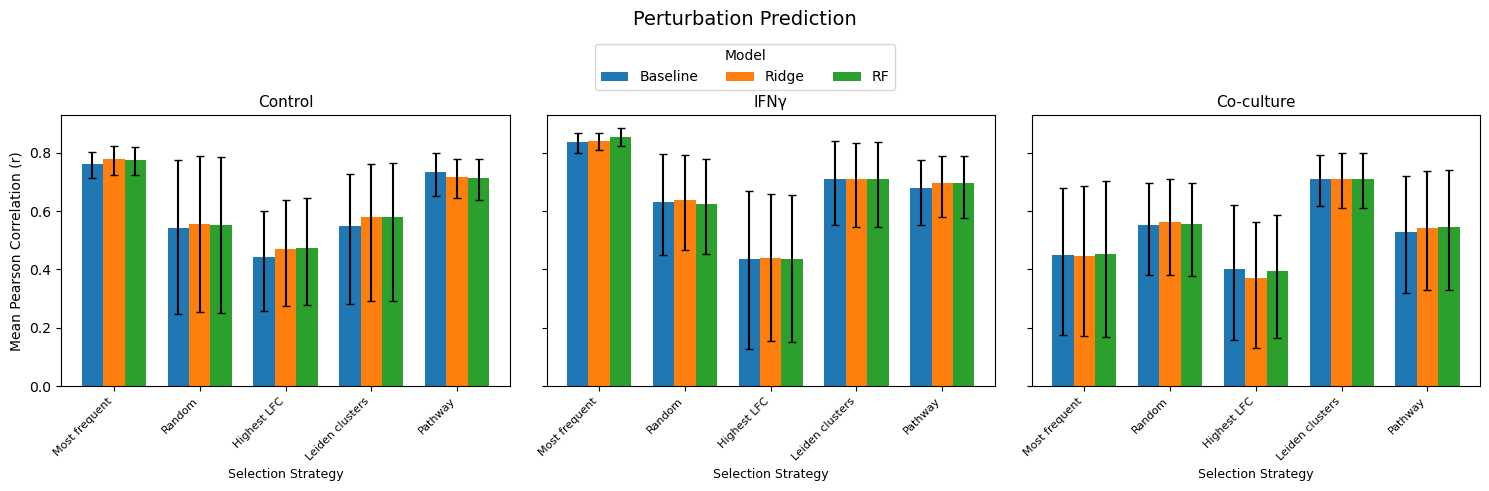

In [75]:
# Visualize Pearson correlation with 95% bootstrap confidence intervals
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

strategies = df_all_results["Strategy"].unique()
conditions = df_all_results["Condition"].unique()

models = [
    "Baseline",
    "Ridge",
    "RF"
]

bar_width = 0.25
x = np.arange(len(strategies))


# Create ONE figure with one subplot per condition
fig, axes = plt.subplots(
    1,
    len(conditions),
    figsize=(15, 4.5),
    sharey=True
)

# If there is only one condition
if len(conditions) == 1:
    axes = [axes]


for i, condition in enumerate(conditions):

    ax = axes[i]

    # Select results for current condition
    df_condition = (
        df_all_results[
            df_all_results["Condition"] == condition
        ]
        .set_index("Strategy")
        .reindex(strategies)
    )

    # Plot Baseline, Ridge and RF
    for j, model in enumerate(models):

        # Mean Pearson correlation
        values = df_condition[
            f"Pearson r {model}"
        ].values

        # Bootstrap confidence intervals
        low = df_condition[
            f"Pearson r {model} low"
        ].values

        high = df_condition[
            f"Pearson r {model} high"
        ].values

        # Convert CI limits to error distances
        lower_error = values - low
        upper_error = high - values

        errors = np.vstack([
            lower_error,
            upper_error
        ])

        # Bar positions
        positions = (
            x
            + (j - 1) * bar_width
        )

        ax.bar(
            positions,
            values,
            width=bar_width,
            label=model,
            yerr=errors,
            capsize=3
        )

    # X-axis
    ax.set_xticks(x)
    ax.set_xticklabels(
        strategies,
        rotation=45,
        ha="right",
        fontsize=8
    )

    # Title for each panel
    ax.set_title(
        str(condition),
        fontsize=11
    )

    ax.set_xlabel(
        "Selection Strategy",
        fontsize=9
    )

    # Only first graph needs y-axis label
    if i == 0:
        ax.set_ylabel(
            "Mean Pearson Correlation (r)",
            fontsize=10
        )


# One common legend for all three graphs
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Model",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=3
)

# Overall title
fig.suptitle(
    "Perturbation Prediction",
    fontsize=14,
    y=1.08
)

plt.tight_layout()


# Save the figure
plt.savefig(
    "Pearson_correlation_all_conditions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

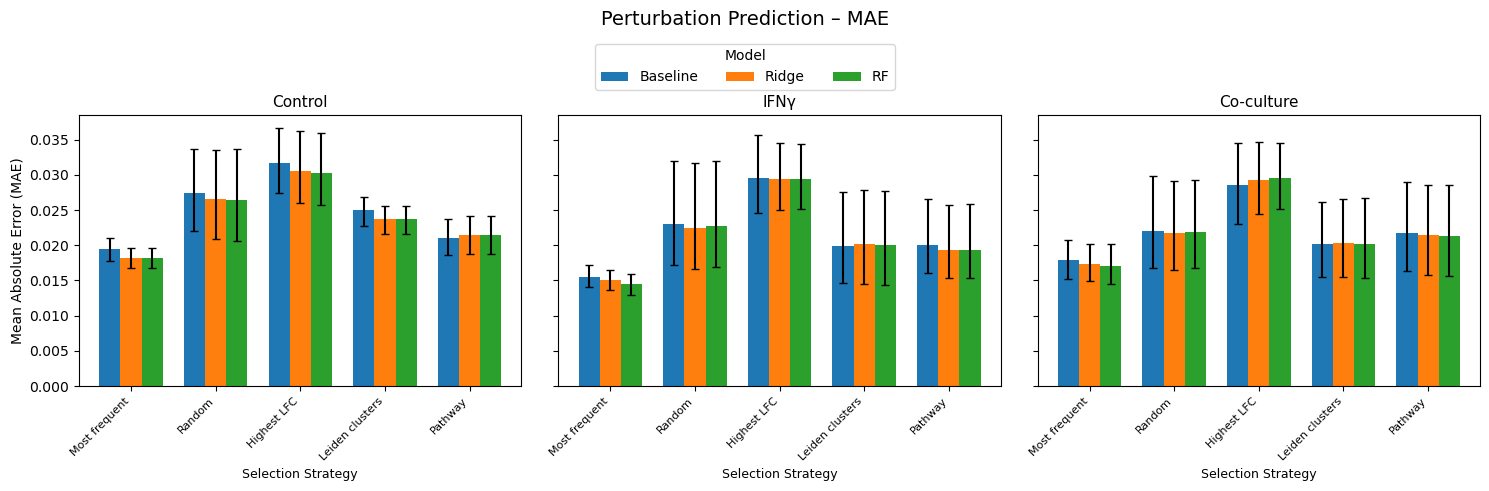

In [77]:
# Visualize MAE with 95% bootstrap confidence intervals

strategies = df_all_results["Strategy"].unique()
conditions = df_all_results["Condition"].unique()

models = [
    "Baseline",
    "Ridge",
    "RF"
]

bar_width = 0.25
x = np.arange(len(strategies))


# Create one figure with one subplot per condition
fig, axes = plt.subplots(
    1,
    len(conditions),
    figsize=(15, 4.5),
    sharey=True
)

# If there is only one condition
if len(conditions) == 1:
    axes = [axes]


# Create one subplot for each experimental condition
for i, condition in enumerate(conditions):

    ax = axes[i]

    # Select results for the current condition
    df_condition = (
        df_all_results[
            df_all_results["Condition"] == condition
        ]
        .set_index("Strategy")
        .reindex(strategies)
    )

    # Plot Baseline, Ridge and RF
    for j, model in enumerate(models):

        # MAE value
        values = df_condition[
            f"MAE {model}"
        ].values

        # Lower and upper limits of the
        # 95% bootstrap confidence interval
        low = df_condition[
            f"MAE {model} low"
        ].values

        high = df_condition[
            f"MAE {model} high"
        ].values

        # Calculate error distances
        lower_error = values - low
        upper_error = high - values

        errors = np.vstack([
            lower_error,
            upper_error
        ])

        # Position model bars next to each other
        positions = (
            x
            + (j - 1) * bar_width
        )

        # Plot MAE with 95% bootstrap error bars
        ax.bar(
            positions,
            values,
            width=bar_width,
            label=model,
            yerr=errors,
            capsize=3
        )

    # X-axis
    ax.set_xticks(x)

    ax.set_xticklabels(
        strategies,
        rotation=45,
        ha="right",
        fontsize=8
    )

    # Condition title
    ax.set_title(
        str(condition),
        fontsize=11
    )

    ax.set_xlabel(
        "Selection Strategy",
        fontsize=9
    )

    # Only first subplot needs y-axis label
    if i == 0:
        ax.set_ylabel(
            "Mean Absolute Error (MAE)",
            fontsize=10
        )


# One common legend for all three plots
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Model",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=3
)

# Overall title
fig.suptitle(
    "Perturbation Prediction – MAE",
    fontsize=14,
    y=1.08
)

plt.tight_layout()


# Save the figure
plt.savefig(
    "MAE_1_bootstrap_DK.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

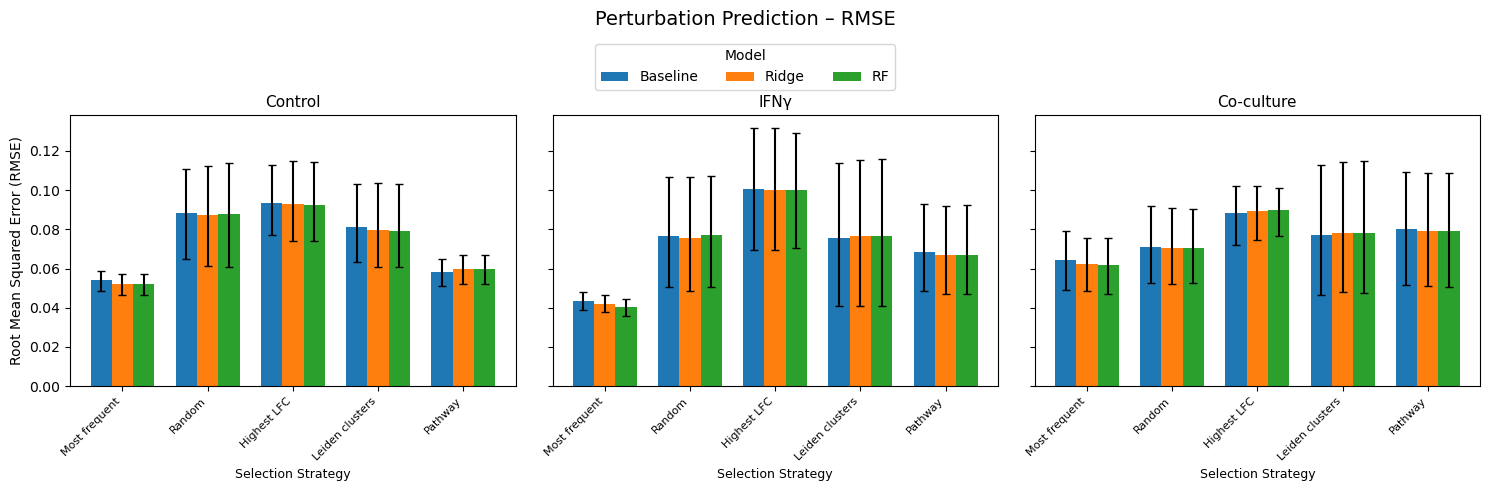

In [78]:
# Visualize RMSE with 95% bootstrap confidence intervals


strategies = df_all_results["Strategy"].unique()
conditions = df_all_results["Condition"].unique()

models = [
    "Baseline",
    "Ridge",
    "RF"
]

bar_width = 0.25
x = np.arange(len(strategies))


# Create one figure with one subplot per condition
fig, axes = plt.subplots(
    1,
    len(conditions),
    figsize=(15, 4.5),
    sharey=True
)

# If there is only one condition
if len(conditions) == 1:
    axes = [axes]


# Create one subplot for each experimental condition
for i, condition in enumerate(conditions):

    ax = axes[i]

    # Select results for the current condition
    df_condition = (
        df_all_results[
            df_all_results["Condition"] == condition
        ]
        .set_index("Strategy")
        .reindex(strategies)
    )

    # Plot Baseline, Ridge and RF
    for j, model in enumerate(models):

        # RMSE value
        values = df_condition[
            f"RMSE {model}"
        ].values

        # Lower and upper limits of the
        # 95% bootstrap confidence interval
        low = df_condition[
            f"RMSE {model} low"
        ].values

        high = df_condition[
            f"RMSE {model} high"
        ].values

        # Calculate error distances
        lower_error = values - low
        upper_error = high - values

        errors = np.vstack([
            lower_error,
            upper_error
        ])

        # Position model bars next to each other
        positions = (
            x
            + (j - 1) * bar_width
        )

        # Plot RMSE with 95% bootstrap error bars
        ax.bar(
            positions,
            values,
            width=bar_width,
            label=model,
            yerr=errors,
            capsize=3
        )

    # X-axis
    ax.set_xticks(x)

    ax.set_xticklabels(
        strategies,
        rotation=45,
        ha="right",
        fontsize=8
    )

    # Condition title
    ax.set_title(
        str(condition),
        fontsize=11
    )

    ax.set_xlabel(
        "Selection Strategy",
        fontsize=9
    )

    # Only first subplot needs y-axis label
    if i == 0:
        ax.set_ylabel(
            "Root Mean Squared Error (RMSE)",
            fontsize=10
        )


# One common legend for all three plots
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Model",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=3
)

# Overall title
fig.suptitle(
    "Perturbation Prediction – RMSE",
    fontsize=14,
    y=1.08
)

plt.tight_layout()


# Save figure
plt.savefig(
    "RMSE_1_bootstrap_DK.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [70]:
# Model 2: Input X does not contain the baseline unperturbed information
# Only pathway information, experimental condition and differently selected 50 perturbation as input

In [71]:
# Train Random Forest, Ridge and baseline for each selection strategy
all_results_2 = []
# Store condition-specific performance results
all_condition_results_2 = []
# Go through each of the selection strategies
for selection_name, selected_50 in selection_sets.items():

    print("\n")
    print("=" * 70)
    print("Selection strategy:", selection_name)
    print("=" * 70)

    # Make sure the perturbations are unique
    selected_50 = list(
        dict.fromkeys(
            selected_50
        )
    )
    # Check the number of selected perturbations
    print(
        "Selected perturbations:",
        len(selected_50)
    )

    if len(selected_50) != 50:

        raise ValueError(
            f"{selection_name} does not contain "
            "exactly 50 unique perturbations."
        )
    
    # Create the transcriptomic response profiles
    profiles = []
    # Go through each experimental condition
    for condition in CONDITIONS:
        # Get the mean expression of the unperturbed control
        # for the current condition
        baseline_mean = baseline_means[
            condition
        ]
        # Go through the 50 selected perturbations
        for pert in selected_50:
            # Select cells belonging to the current
            # perturbation and condition
            pert_mask = (
                (adata.obs[COND_COL] == condition)
                &
                (adata.obs[PERT_COL] == pert)
            )

            pert_adata = adata[
                pert_mask
            ]
            pert_mean = mean_expression(
                pert_adata,
                response_genes
            )

            # Calculate log2FC relative to the
            # condition-matched unperturbed control
            log2fc = np.log2(
                (pert_mean + PSEUDOCOUNT)
                /
                (baseline_mean + PSEUDOCOUNT)
            )

            profiles.append({

                "perturbation":
                    pert,

                "condition":
                    condition,

                "n_cells":
                    pert_adata.n_obs,

                "log2fc":
                    log2fc
            })
    # Create metadata and target matrix Y
    
    profile_metadata = pd.DataFrame([
        {
            "perturbation":
                p["perturbation"],

            "condition":
                p["condition"],

            "n_cells":
                p["n_cells"]
        }

        for p in profiles
    ])

    # Combine the log2FC profiles into the target matrix Y
    # Each row represents one perturbation-condition profile
    # and each column represents one response gene
    Y = np.vstack([
        p["log2fc"]
        for p in profiles
    ])


    print(
        "Profiles:",
        profile_metadata.shape
    )

    print(
        "Y:",
        Y.shape
    )

  
    # Create Model 2 input matrix X
    #
    # Input features:
    # 1. Hallmark pathway annotations
    # 2. Experimental condition
    # Create an empty list to store the input features
    X_rows_2 = []
    # Go through each perturbation-condition profile
    for _, row in profile_metadata.iterrows():
        # Get the perturbation gene
        gene = row[
            "perturbation"
        ]
        # Get the experimental condition
        condition = row[
            "condition"
        ]


        # Hallmark pathway annotations
        features = pathway_matrix.loc[
            gene
        ].copy()


        # Experimental condition
        features[
            "condition_Control"
        ] = int(
            condition == "Control"
        )

        features[
            "condition_IFNγ"
        ] = int(
            condition == "IFNγ"
        )

        features[
            "condition_Co-culture"
        ] = int(
            condition == "Co-culture"
        )


        X_rows_2.append(
            features
        )

    # Combine the input features from all
    # perturbation-condition profiles into one DataFrame.
    # Each row of X represents one perturbation under one condition,
    # and the columns contain the features used by the models.
    X_no_baseline = pd.DataFrame(
        X_rows_2
    ).reset_index(drop=True)


    print(
        "X_no_baseline:",
        X_no_baseline.shape
    )

    # Split the 50 selected perturbations into
    # 40 training and 10 held-out test perturbations

    rng_split = np.random.default_rng(
        RANDOM_STATE
    )

    selected_array = np.array(
        selected_50
    )

    rng_split.shuffle(
        selected_array
    )

    # Select 10 perturbations for the test set
    test_genes = selected_array[
        :10
    ].tolist()

    # Use the remaining 40 perturbations for training
    train_genes = selected_array[
        10:
    ].tolist()

    print(
        "Training perturbations:",
        len(train_genes)
    )

    print(
        "Test perturbations:",
        len(test_genes)
    )
    # Create train and test datasets
    train_mask = (
        profile_metadata[
            "perturbation"
        ]
        .isin(
            train_genes
        )
    )

    test_mask = (
        profile_metadata[
            "perturbation"
        ]
        .isin(
            test_genes
        )
    )


    X_train_2 = (
        X_no_baseline.loc[
            train_mask
        ]
        .reset_index(
            drop=True
        )
    )

    X_test_2 = (
        X_no_baseline.loc[
            test_mask
        ]
        .reset_index(
            drop=True
        )
    )


    Y_train_2 = Y[
        train_mask.values
    ]

    Y_test_2 = Y[
        test_mask.values
    ]

    meta_train = (
        profile_metadata.loc[
            train_mask
        ]
        .reset_index(
            drop=True
        )
    )

    meta_test = (
        profile_metadata.loc[
            test_mask
        ]
        .reset_index(
            drop=True
        )
    )


    print(
        "X_train_2:",
        X_train_2.shape
    )

    print(
        "X_test_2:",
        X_test_2.shape
    )

    print(
        "Y_train_2:",
        Y_train_2.shape
    )

    print(
        "Y_test_2:",
        Y_test_2.shape
    )

    # Reduce the 2,000-gene response to 50 PCs

    pca_y = PCA(
        n_components=N_TARGET_PCS,
        random_state=RANDOM_STATE
    )


    # PCA is fitted only on training data
    Y_train_pca = (
        pca_y.fit_transform(
            Y_train_2
        )
    )


    Y_test_pca = (
        pca_y.transform(
            Y_test_2
        )
    )


    print(
        "Explained variance by 50 PCs:",
        pca_y.explained_variance_ratio_
        .sum()
    )

    # Grouped cross-validation

    train_groups = (
        meta_train[
            "perturbation"
        ]
        .values
    )


    cv = GroupKFold(
        n_splits=5
    )


    # RANDOM FOREST


    rf = RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1
    )


    rf_search = RandomizedSearchCV(

        estimator=rf,

        param_distributions=
            rf_param_dist,

        n_iter=6,

        scoring=
            "neg_mean_squared_error",

        cv=cv,

        random_state=
            RANDOM_STATE,

        n_jobs=-1,

        verbose=0
    )


    rf_search.fit(
        X_train_2,
        Y_train_pca,
        groups=train_groups
    )


    best_rf = (
        rf_search
        .best_estimator_
    )


    # Predict test profiles
    Y_pred_pca_rf = (
        best_rf.predict(
            X_test_2
        )
    )


    # Return to 2,000-gene space
    Y_pred_rf = (
        pca_y.inverse_transform(
            Y_pred_pca_rf
        )
    )

    # RIDGE REGRESSION

    ridge = Ridge()


    ridge_search = GridSearchCV(

        estimator=ridge,

        param_grid=
            ridge_param_grid,

        scoring=
            "neg_mean_squared_error",

        cv=cv,

        n_jobs=-1
    )


    ridge_search.fit(
        X_train_2,
        Y_train_pca,
        groups=train_groups
    )


    best_ridge = (
        ridge_search
        .best_estimator_
    )


    # Predict the test profiles
    Y_pred_pca_ridge = (
        best_ridge.predict(
            X_test_2
        )
    )


    # Return to 2,000-gene space
    Y_pred_ridge = (
        pca_y.inverse_transform(
            Y_pred_pca_ridge
        )
    )
    # DUMMY REGRESSOR BASELINE

    from sklearn.dummy import DummyRegressor

    # Create a simple baseline model that always predicts
    # the mean response of the training data
    dummy = DummyRegressor(
        strategy="mean"
    )
    
    # Fit the baseline model
    dummy.fit(
        X_train_2,
        Y_train_pca
    )
    
    # Predict the test profiles
    Y_pred_pca_dummy = dummy.predict(
        X_test_2
    )
    
    # Transform the predictions back to the
    # original 2,000-gene log2FC space
    Y_pred_dummy = pca_y.inverse_transform(
        Y_pred_pca_dummy
    )
        
    # Evaluate Random Forest, Ridge and baseline model separately for each condition

    for condition in CONDITIONS:
    
        # Select test profiles belonging to the current condition
        condition_mask = (
            meta_test["condition"] == condition
        ).to_numpy()
    
        Y_true_condition = Y_test_2[
            condition_mask
        ]
    
        Y_pred_rf_condition = Y_pred_rf[
            condition_mask
        ]
    
        Y_pred_ridge_condition = Y_pred_ridge[
            condition_mask
        ]
        # Dummy baseline predictions for the current condition
        Y_pred_dummy_condition = Y_pred_dummy[
        condition_mask
        ]
        # Random Forest performance
    
        mae_rf_condition = mean_absolute_error(
            Y_true_condition.ravel(),
            Y_pred_rf_condition.ravel()
        )
    
        rmse_rf_condition = np.sqrt(
            mean_squared_error(
                Y_true_condition.ravel(),
                Y_pred_rf_condition.ravel()
            )
        )
    
        pearson_rf_condition = []
    
        for i in range(len(Y_true_condition)):
    
            if (
                np.std(Y_true_condition[i]) > 0
                and
                np.std(Y_pred_rf_condition[i]) > 0
            ):
    
                r, _ = pearsonr(
                    Y_true_condition[i],
                    Y_pred_rf_condition[i]
                )
    
                pearson_rf_condition.append(r)
    
        mean_pearson_rf_condition = np.nanmean(
            pearson_rf_condition
        )
    
    
        
        # Ridge performance
       
        mae_ridge_condition = mean_absolute_error(
            Y_true_condition.ravel(),
            Y_pred_ridge_condition.ravel()
        )
    
        rmse_ridge_condition = np.sqrt(
            mean_squared_error(
                Y_true_condition.ravel(),
                Y_pred_ridge_condition.ravel()
            )
        )
    
        pearson_ridge_condition = []
    
        for i in range(len(Y_true_condition)):
    
            if (
                np.std(Y_true_condition[i]) > 0
                and
                np.std(Y_pred_ridge_condition[i]) > 0
            ):
    
                r, _ = pearsonr(
                    Y_true_condition[i],
                    Y_pred_ridge_condition[i]
                )
    
                pearson_ridge_condition.append(r)
    
        mean_pearson_ridge_condition = np.nanmean(
            pearson_ridge_condition
        )
    
                # Dummy baseline performance
        
        mae_dummy_condition = mean_absolute_error(
            Y_true_condition.ravel(),
            Y_pred_dummy_condition.ravel()
        )
        
        rmse_dummy_condition = np.sqrt(
            mean_squared_error(
                Y_true_condition.ravel(),
                Y_pred_dummy_condition.ravel()
            )
        )
        
        pearson_dummy_condition = []
        
        for i in range(len(Y_true_condition)):
        
            if (
                np.std(Y_true_condition[i]) > 0
                and
                np.std(Y_pred_dummy_condition[i]) > 0
            ):
        
                r, _ = pearsonr(
                    Y_true_condition[i],
                    Y_pred_dummy_condition[i]
                )
        
                pearson_dummy_condition.append(r)
        
        mean_pearson_dummy_condition = np.nanmean(
            pearson_dummy_condition
        )
            
                # Get the metadata for the current condition
        meta_condition = (
            meta_test.loc[
                condition_mask
            ]
            .reset_index(drop=True)
        )
        
        
        # Calculate 95% bootstrap confidence intervals
        # for Random Forest
        mae_ci_rf, rmse_ci_rf, pearson_ci_rf = bootstrap_metrics(
            Y_true_condition,
            Y_pred_rf_condition,
            meta_condition,
            n_bootstraps=1000,
            random_state=42
        )
        
        
        # Calculate 95% bootstrap confidence intervals
        # for Ridge Regression
        mae_ci_ridge, rmse_ci_ridge, pearson_ci_ridge = bootstrap_metrics(
            Y_true_condition,
            Y_pred_ridge_condition,
            meta_condition,
            n_bootstraps=1000,
            random_state=42
        )
        
        
        # Calculate 95% bootstrap confidence intervals
        # for the Dummy baseline
        mae_ci_dummy, rmse_ci_dummy, pearson_ci_dummy = bootstrap_metrics(
            Y_true_condition,
            Y_pred_dummy_condition,
            meta_condition,
            n_bootstraps=1000,
            random_state=42
        )
    
       # Store results

       # Store performance results and 95% bootstrap confidence intervals
        all_condition_results_2.append({
        
            "Strategy": selection_name,
            "Condition": condition,
        
            # Dummy baseline
            "MAE Baseline": mae_dummy_condition,
            "MAE Baseline low": mae_ci_dummy[0],
            "MAE Baseline high": mae_ci_dummy[1],
        
            "RMSE Baseline": rmse_dummy_condition,
            "RMSE Baseline low": rmse_ci_dummy[0],
            "RMSE Baseline high": rmse_ci_dummy[1],
        
            "Pearson r Baseline": mean_pearson_dummy_condition,
            "Pearson r Baseline low": pearson_ci_dummy[0],
            "Pearson r Baseline high": pearson_ci_dummy[1],
        
            # Ridge Regression
            "MAE Ridge": mae_ridge_condition,
            "MAE Ridge low": mae_ci_ridge[0],
            "MAE Ridge high": mae_ci_ridge[1],
        
            "RMSE Ridge": rmse_ridge_condition,
            "RMSE Ridge low": rmse_ci_ridge[0],
            "RMSE Ridge high": rmse_ci_ridge[1],
        
            "Pearson r Ridge": mean_pearson_ridge_condition,
            "Pearson r Ridge low": pearson_ci_ridge[0],
            "Pearson r Ridge high": pearson_ci_ridge[1],
        
            # Random Forest
            "MAE RF": mae_rf_condition,
            "MAE RF low": mae_ci_rf[0],
            "MAE RF high": mae_ci_rf[1],
        
            "RMSE RF": rmse_rf_condition,
            "RMSE RF low": rmse_ci_rf[0],
            "RMSE RF high": rmse_ci_rf[1],
        
            "Pearson r RF": mean_pearson_rf_condition,
            "Pearson r RF low": pearson_ci_rf[0],
            "Pearson r RF high": pearson_ci_rf[1]
        })



Selection strategy: Most frequent
Selected perturbations: 50
Profiles: (150, 3)
Y: (150, 2000)
X_no_baseline: (150, 53)
Training perturbations: 40
Test perturbations: 10
X_train_2: (120, 53)
X_test_2: (30, 53)
Y_train_2: (120, 2000)
Y_test_2: (30, 2000)
Explained variance by 50 PCs: 0.9344314


Selection strategy: Random
Selected perturbations: 50
Profiles: (150, 3)
Y: (150, 2000)
X_no_baseline: (150, 53)
Training perturbations: 40
Test perturbations: 10
X_train_2: (120, 53)
X_test_2: (30, 53)
Y_train_2: (120, 2000)
Y_test_2: (30, 2000)
Explained variance by 50 PCs: 0.93879634


Selection strategy: Highest LFC
Selected perturbations: 50
Profiles: (150, 3)
Y: (150, 2000)
X_no_baseline: (150, 53)
Training perturbations: 40
Test perturbations: 10
X_train_2: (120, 53)
X_test_2: (30, 53)
Y_train_2: (120, 2000)
Y_test_2: (30, 2000)
Explained variance by 50 PCs: 0.9337108


Selection strategy: Leiden clusters
Selected perturbations: 50
Profiles: (150, 3)
Y: (150, 2000)
X_no_baseline: (150, 

In [72]:
# Create final condition-specific results table

df_all_results_2 = pd.DataFrame(
    all_condition_results_2
)

In [ ]:
# Show all performance results including 95% bootstrap CIs
pd.set_option(
    "display.max_columns",
    None
)

display(
    df_all_results_2.round(3)
)

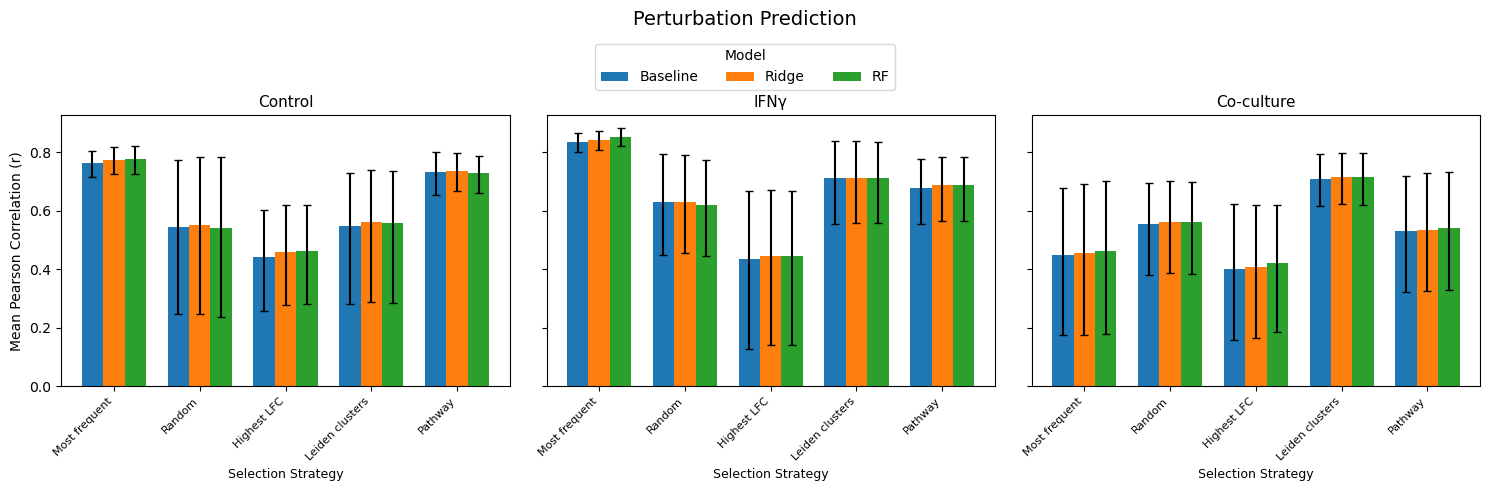

In [79]:
# Visualize Pearson correlation with 95% bootstrap confidence intervals
strategies = df_all_results_2["Strategy"].unique()
conditions = df_all_results_2["Condition"].unique()

models = [
    "Baseline",
    "Ridge",
    "RF"
]

bar_width = 0.25
x = np.arange(len(strategies))


# Create one figure with one subplot per condition
fig, axes = plt.subplots(
    1,
    len(conditions),
    figsize=(15, 4.5),
    sharey=True
)

# If there is only one condition
if len(conditions) == 1:
    axes = [axes]


for i, condition in enumerate(conditions):

    ax = axes[i]

    # Select results for current condition
    df_condition = (
        df_all_results_2[
            df_all_results_2["Condition"] == condition
        ]
        .set_index("Strategy")
        .reindex(strategies)
    )

    # Plot Baseline, Ridge and RF
    for j, model in enumerate(models):

        # Mean Pearson correlation
        values = df_condition[
            f"Pearson r {model}"
        ].values

        # Bootstrap confidence intervals
        low = df_condition[
            f"Pearson r {model} low"
        ].values

        high = df_condition[
            f"Pearson r {model} high"
        ].values

        # Convert CI limits to error distances
        lower_error = values - low
        upper_error = high - values

        errors = np.vstack([
            lower_error,
            upper_error
        ])

        # Bar positions
        positions = (
            x
            + (j - 1) * bar_width
        )

        ax.bar(
            positions,
            values,
            width=bar_width,
            label=model,
            yerr=errors,
            capsize=3
        )

    # X-axis
    ax.set_xticks(x)
    ax.set_xticklabels(
        strategies,
        rotation=45,
        ha="right",
        fontsize=8
    )

    # Title for each panel
    ax.set_title(
        str(condition),
        fontsize=11
    )

    ax.set_xlabel(
        "Selection Strategy",
        fontsize=9
    )

    # Only first graph needs y-axis label
    if i == 0:
        ax.set_ylabel(
            "Mean Pearson Correlation (r)",
            fontsize=10
        )


# One common legend for all three graphs
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Model",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=3
)

# Overall title
fig.suptitle(
    "Perturbation Prediction",
    fontsize=14,
    y=1.08
)

plt.tight_layout()


# Save the figure
plt.savefig(
    "Pearson_correlation_all_conditions_2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

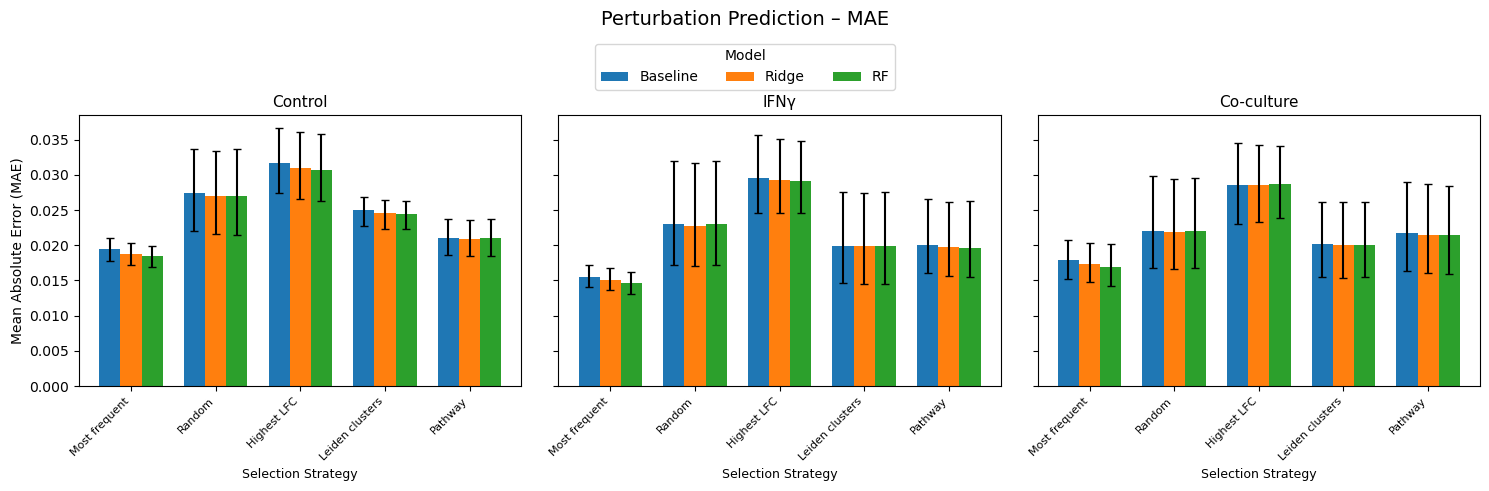

In [83]:
# Visualize MAE with 95% bootstrap confidence intervals

strategies = df_all_results_2["Strategy"].unique()
conditions = df_all_results_2["Condition"].unique()

models = [
    "Baseline",
    "Ridge",
    "RF"
]

bar_width = 0.25
x = np.arange(len(strategies))


# Create one figure with one subplot per condition
fig, axes = plt.subplots(
    1,
    len(conditions),
    figsize=(15, 4.5),
    sharey=True
)

# If there is only one condition
if len(conditions) == 1:
    axes = [axes]


# Create one subplot for each experimental condition
for i, condition in enumerate(conditions):

    ax = axes[i]

    # Select results for the current condition
    df_condition = (
        df_all_results_2[
            df_all_results_2["Condition"] == condition
        ]
        .set_index("Strategy")
        .reindex(strategies)
    )

    # Plot Baseline, Ridge and RF
    for j, model in enumerate(models):

        # MAE value
        values = df_condition[
            f"MAE {model}"
        ].values

        # Lower and upper limits of the
        # 95% bootstrap confidence interval
        low = df_condition[
            f"MAE {model} low"
        ].values

        high = df_condition[
            f"MAE {model} high"
        ].values

        # Calculate error distances
        lower_error = values - low
        upper_error = high - values

        errors = np.vstack([
            lower_error,
            upper_error
        ])

        # Position model bars next to each other
        positions = (
            x
            + (j - 1) * bar_width
        )

        # Plot MAE with 95% bootstrap error bars
        ax.bar(
            positions,
            values,
            width=bar_width,
            label=model,
            yerr=errors,
            capsize=3
        )

    # X-axis
    ax.set_xticks(x)

    ax.set_xticklabels(
        strategies,
        rotation=45,
        ha="right",
        fontsize=8
    )

    # Condition title
    ax.set_title(
        str(condition),
        fontsize=11
    )

    ax.set_xlabel(
        "Selection Strategy",
        fontsize=9
    )

    # Only first subplot needs y-axis label
    if i == 0:
        ax.set_ylabel(
            "Mean Absolute Error (MAE)",
            fontsize=10
        )


# One common legend for all three plots
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Model",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=3
)

# Overall title
fig.suptitle(
    "Perturbation Prediction – MAE",
    fontsize=14,
    y=1.08
)

plt.tight_layout()


# Save as figure
plt.savefig(
    "MAE_2_bootstrap_DK.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

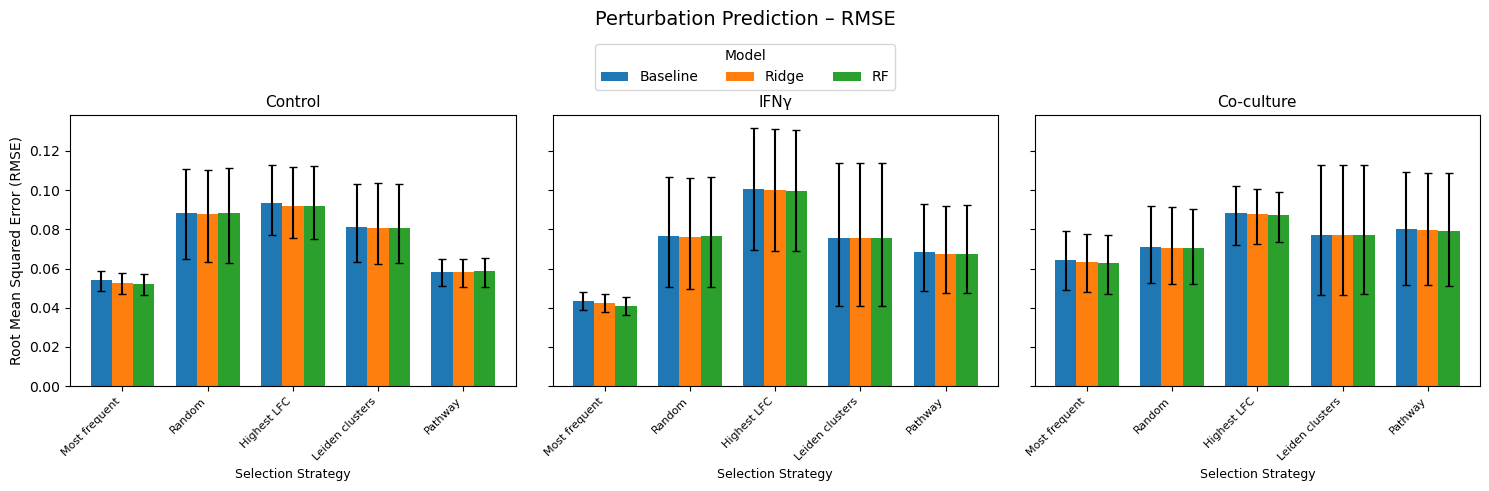

In [84]:
# Visualize RMSE with 95% bootstrap confidence intervals

strategies = df_all_results_2["Strategy"].unique()
conditions = df_all_results_2["Condition"].unique()

models = [
    "Baseline",
    "Ridge",
    "RF"
]

bar_width = 0.25
x = np.arange(len(strategies))


# Create one figure with one subplot per condition
fig, axes = plt.subplots(
    1,
    len(conditions),
    figsize=(15, 4.5),
    sharey=True
)

# If there is only one condition
if len(conditions) == 1:
    axes = [axes]


# Create one subplot for each experimental condition
for i, condition in enumerate(conditions):

    ax = axes[i]

    # Select results for the current condition
    df_condition = (
        df_all_results_2[
            df_all_results_2["Condition"] == condition
        ]
        .set_index("Strategy")
        .reindex(strategies)
    )

    # Plot Baseline, Ridge and RF
    for j, model in enumerate(models):

        # RMSE value
        values = df_condition[
            f"RMSE {model}"
        ].values

        # Lower and upper limits of the
        # 95% bootstrap confidence interval
        low = df_condition[
            f"RMSE {model} low"
        ].values

        high = df_condition[
            f"RMSE {model} high"
        ].values

        # Calculate error distances
        lower_error = values - low
        upper_error = high - values

        errors = np.vstack([
            lower_error,
            upper_error
        ])

        # Position model bars next to each other
        positions = (
            x
            + (j - 1) * bar_width
        )

        # Plot RMSE with 95% bootstrap error bars
        ax.bar(
            positions,
            values,
            width=bar_width,
            label=model,
            yerr=errors,
            capsize=3
        )

    # X-axis
    ax.set_xticks(x)

    ax.set_xticklabels(
        strategies,
        rotation=45,
        ha="right",
        fontsize=8
    )

    # Condition title
    ax.set_title(
        str(condition),
        fontsize=11
    )

    ax.set_xlabel(
        "Selection Strategy",
        fontsize=9
    )

    # Only first subplot needs y-axis label
    if i == 0:
        ax.set_ylabel(
            "Root Mean Squared Error (RMSE)",
            fontsize=10
        )


# One common legend for all three plots
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Model",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=3
)

# Overall title
fig.suptitle(
    "Perturbation Prediction – RMSE",
    fontsize=14,
    y=1.08
)

plt.tight_layout()


# Save the figure
plt.savefig(
    "RMSE_2_bootstrap_DK.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Visualize the model performances as tables for both models
# 1. Input features: 50 differently selected features, Hallmark pathways, conditions, unperturbed baseline information
# 2. Input features: 50 differently selected features, Hallmark pathways, conditions

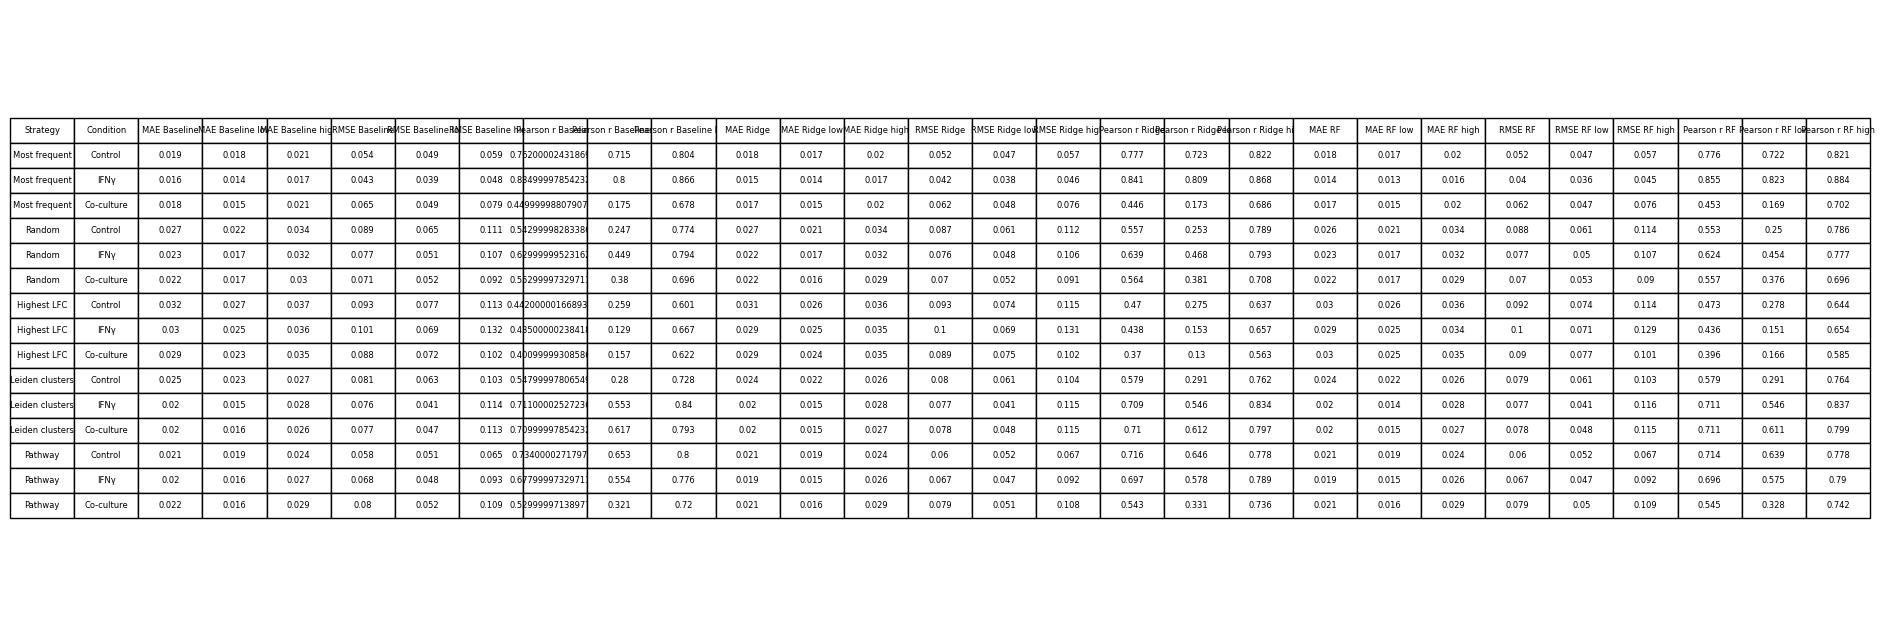

In [85]:
import matplotlib.pyplot as plt
# 1. Input features: 50 differently selected features, Hallmark pathways, conditions, unperturbed baseline information
# Select the first 15 rows
df_save = df_all_results.head(15).round(3)

# Create figure
fig, ax = plt.subplots(
    figsize=(24, 8)
)

# Remove axes
ax.axis("off")

# Create table
table = ax.table(
    cellText=df_save.values,
    colLabels=df_save.columns,
    loc="center",
    cellLoc="center"
)

# Adjust table appearance
table.auto_set_font_size(False)
table.set_fontsize(6)
table.scale(1, 1.5)

# Save as PNG
plt.savefig(
    "Task3_results.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

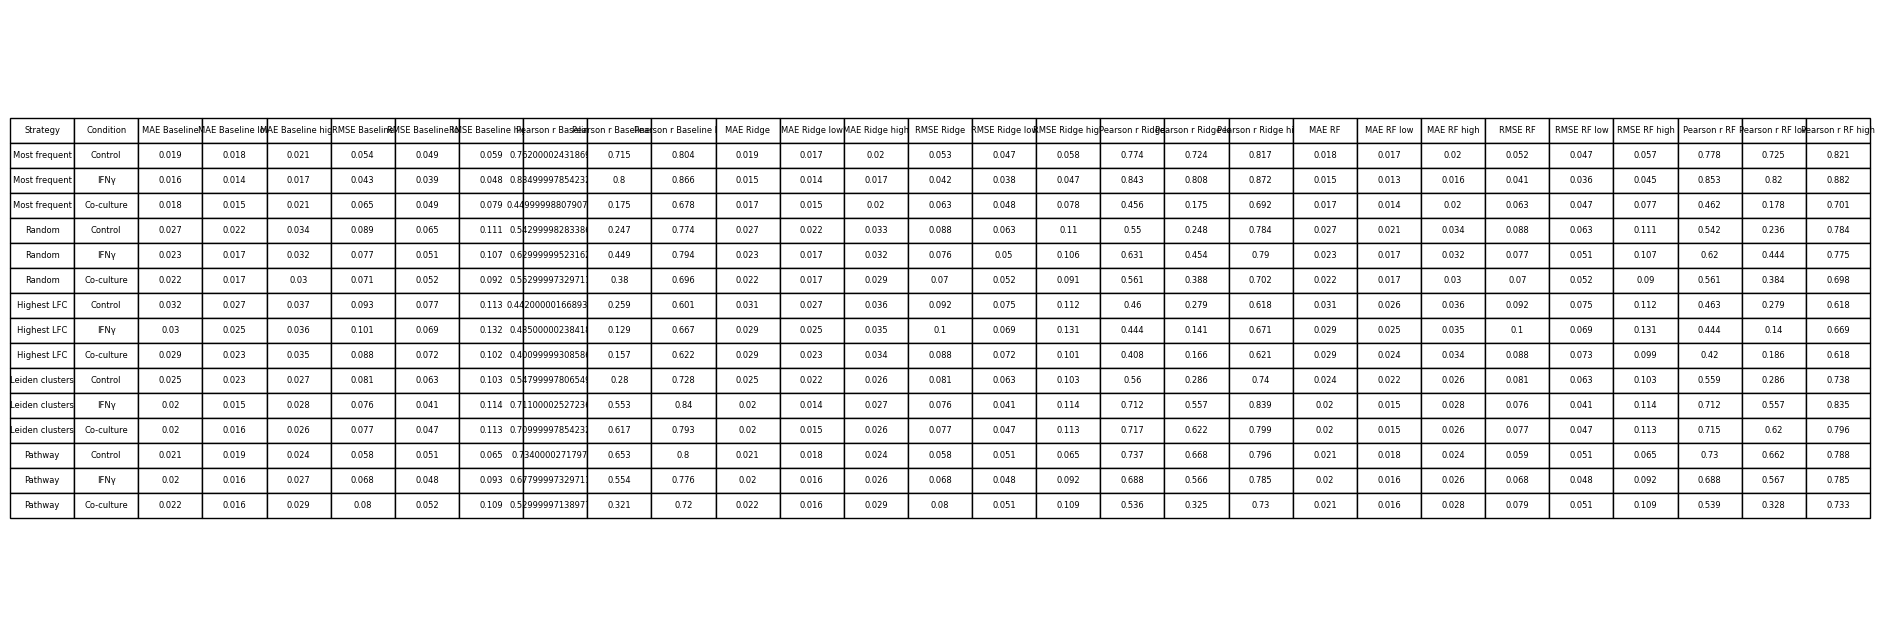

In [86]:
import matplotlib.pyplot as plt
# Input features: 50 differently selected features, Hallmark pathways, conditions
# Select the first 15 rows
df_save = df_all_results_2.head(15).round(3)

# Create figure
fig, ax = plt.subplots(
    figsize=(24, 8)
)

# Remove axes
ax.axis("off")

# Create table
table = ax.table(
    cellText=df_save.values,
    colLabels=df_save.columns,
    loc="center",
    cellLoc="center"
)

# Adjust table appearance
table.auto_set_font_size(False)
table.set_fontsize(6)
table.scale(1, 1.5)

# Save as PNG
plt.savefig(
    "Task3_results_no_baseline.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()